In [1]:
# these are the libraries that we need for our project
import pandas as pd

# Collection

I obtain data and inspect it.

In [2]:
data_path = "data/Pan-India_Bus_Routes.csv"

In [3]:
# ensure that all rows of a dataframe are displayed in the output. This will be useful for the value_counts() method
pd.set_option('display.max_rows', None)

bus_df = pd.read_csv(data_path, sep=",")

There is 35667 entries in this dataframe. Each refers to a bus route from one city to another, rather than to the bus itself. Therefore, we do not know how many buses are there, and how many of them have traits, such as A/C or Sleeper. However, we know for sure one thing. That those traits apply to the trip undertaken on the bus. And therefore, the business insights that we extract from the data can be applied to the bus trips, as they, themselves, are unique, and are what we are looking to improve based on insights from data.

In [4]:
bus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35667 entries, 0 to 35666
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   From       35667 non-null  object
 1   To         35667 non-null  object
 2   Operator   35667 non-null  object
 3   Distance   35667 non-null  int64 
 4   Duration   35667 non-null  object
 5   Bus Type   35667 non-null  object
 6   Departure  35667 non-null  object
 7   Arrival    35667 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.2+ MB


In [5]:
# no Null values thus far. But there may be other ways, in which the data is incomplete
bus_df.isnull().sum()

From         0
To           0
Operator     0
Distance     0
Duration     0
Bus Type     0
Departure    0
Arrival      0
dtype: int64

In [6]:

with open("data/bus_starting_output.txt", "w") as f:
  print(bus_df["From"].value_counts(dropna=False), file=f)

In [7]:

with open("data/bus_destination_output.txt", "w") as f:
  print(bus_df["To"].value_counts(dropna=False), file=f)

Findings:
+ All origins and destinations are properly capitalized, and most of them have correct formatting. 
+ No rows have missing city names for origin or destination
+ Some places have "bypass" in their names. The number of routes with those places may be statistically insignificant
    + But it is still worthwhile to find out how to treat them properly


In [8]:
with open("data/bus_operator_output.txt", "w") as f:
  print(bus_df["Operator"].value_counts(dropna=False), file=f)

For operators, it's more complicated:
+ Different operators have very similar names
    + i.e. sharma travels (nanded)-(chintamani) and sharma travels (nanded)-devgiri express-VT
    + Are they the parts of the same company? Or should they be treated as separate entities?
    + there are many such cases, so this is a more important problem than the "bypass" problem mentioned above.

In [9]:
with open("data/bus_distance_output.txt", "w") as f:
  print(bus_df["Distance"].value_counts(dropna=False, normalize=True), file=f)

Distance between cities measured in kilometers - pretty straightforward. Distances of hundreds of kilometers are common, but that's not surprising.

In [10]:
with open("data/travel_duration_output.txt", "w") as f:
  print(bus_df["Duration"].value_counts(dropna=False), file=f)

The original dataset claims that duration is in the format "hh:mm:ss", but that is wrong. The second number in the timestamp is never greater than 23, implying that it is the hour, and not the minute. Moreover, distances between cities are so long, that it is impossible to clear them in mere hours. Therefore, the more appropriate timestamp format would be "d:hh:mm".

Later, I will convert the "Duration" column into a proper timestamp recognized by pandas

In [11]:
with open("data/bus_type_output.txt", "w") as f:
  print(bus_df["Bus Type"].value_counts(dropna=False), file=f)

This is the most difficult column to clean. We must split it into several different columns, each containing the following information:
+ sleeper vs non-sleeper - represents the extent, to which this bus is designed for sleeping
+ brand of bus
+ seat configuration(2+2, 1+2, etc.) - represents # of seats per row
+ AC vs non-AC - presence of air conditioning
+ miscellaneous - descriptions that do not fit into any of the above categories

In [12]:
with open("data/departure_time_output.txt", "w") as f:
  print(bus_df["Departure"].value_counts(dropna=False), file=f)

In [13]:
with open("data/arrival_time_output.txt", "w") as f:
  print(bus_df["Arrival"].value_counts(dropna=False), file=f)

Both departure and arrival follow the same straightforward scheme. hh:mm:ss 12-hour format.
Must convert them to proper timestamp format

# Cleaning

I clean up data by changing format and splitting the "Bus Type" column into many smaller types.

In [14]:
import regex as re

# I cloned this dataframe, so that it's easier to trace it.
bus_df_v2 = bus_df.copy()
# Convert Bus Type column to lowercase to simplify detection

bt = bus_df_v2["Bus Type"].str.lower()

In [15]:


# this code will separate the many values inside the Bus Type column into something useful.
# 1. Detect explicit Non-AC
non_ac_pat = r"non a/c|non-ac|nonac|non ac"
has_non_ac = bt.str.contains(non_ac_pat)

# 2. Detect explicit AC (but not "non ac")
ac_pat = r"\ba/c\b|\bac\b"
has_ac = bt.str.contains(ac_pat)

# 3. Single 'has_ac' column:
#    - True  = explicitly AC and not Non-AC
#    - False = explicitly Non-AC and not AC
#    - NaN   = ambiguous or neither mentioned
bus_df_v2["has_ac"] = pd.Series(pd.NA, index=bus_df_v2.index, dtype="boolean")

bus_df_v2.loc[has_ac & ~has_non_ac, "has_ac"] = True      # definite AC
bus_df_v2.loc[has_non_ac, "has_ac"] = False     # definite Non-AC
# bus_df_v2.loc[has_ac & has_non_ac, "has_ac"] = pd.NA      
# weird strings like "Non A/c  A/c"
# rows where neither has_ac nor has_non_ac stay as NaN

In [16]:

# 1. Detect Semi-Sleeper first
semi_pat = r"semi[\s-]?sleeper"
is_semi_sleeper = bt.str.contains(semi_pat)

# 2. Any mention of "sleeper" at all
has_sleeper_word = bt.str.contains("sleeper")

# -------- Sleeper vs Semi-Sleeper (no overlap) --------
bus_df_v2["sleeper_category"] = pd.Series(pd.NA, index=bus_df_v2.index, dtype="object")


# 3. Separate columns:
#    - is_semi_sleeper: True/False (simple boolean)
#    - is_sleeper: True if sleeper but not semi-sleeper, NaN otherwise
bus_df_v2.loc[is_semi_sleeper, "sleeper_category"] = "Semi-Sleeper"
bus_df_v2.loc[has_sleeper_word & ~is_semi_sleeper, "sleeper_category"] = "Sleeper"
bus_df_v2.loc[~has_sleeper_word & ~is_semi_sleeper, "sleeper_category"] = "Other"

# if a bus is neither sleeper nor semi-sleeper, "sleeper_category" is "Other"

In [17]:
bus_df_v2["is_seater"]      = bt.str.contains("seater|seat")
bus_df_v2["is_multiaxle"]   = bt.str.contains("multi")
bus_df_v2["has_video"]      = bt.str.contains("video")
bus_df_v2["is_pushback"]    = bt.str.contains("push")
# there are many different seat formats, but majority of values obeys a similar formatting
seat_format_pat = r"(\d\s*[\+x]\s*\d)"
bus_df_v2["seat_format"] = bt.str.extract(seat_format_pat, expand=False)# use Regex to turn "brand" into a separate categorical variable. More convenient than creating booleans for each brand
bus_df_v2["brand"]       = bt.str.extract(r"(volvo|mercedes|isuzu|king long)", flags=re.IGNORECASE)

Afterwards, I save the snapshot of the dataframe to CSV, so that it's easier to retrace steps in case smth got lost.

In [18]:
bus_df_v2.to_csv("data/Pan-India_Bus_Routes_v2.csv")

In [19]:
bus_df_v2.head()

,From,To,Operator,Distance,Duration,Bus Type,Departure,Arrival,has_ac,sleeper_category,is_seater,is_multiaxle,has_video,is_pushback,seat_format,brand
0,Sattur,Chennai,PERINBA VILAS TRAVELS,539,0:9:0,"A/C, 35 Seat, 2+2 Semi Sleeper, Air Suspensio...",09:30:00 PM,06:30:00 AM,True,Semi-Sleeper,True,False,False,False,2+2,NaN
1,Sattur,Chennai,PERINBA VILAS TRAVELS,539,0:10:45,"Non A/C, 34 Seat, 2+1 Executive, Air Suspensio...",07:45:00 PM,06:30:00 AM,False,Other,True,False,False,False,2+1,NaN
2,Sattur,Chennai,KPN Travels,539,0:9:45,2+2 : 33 S.S NON A/C,07:45:00 PM,05:30:00 AM,False,Other,False,False,False,False,2+2,NaN
3,Sattur,Salem,Srs Travels (SRS Travels),304,0:5:45,"2+1, Sleeper, AC, Non-Video",09:45:00 PM,03:30:00 AM,True,Sleeper,False,False,True,False,2+1,NaN
4,Sattur,Coimbatore,India Travel Service,295,0:6:40,2+2 Hitech Air Bus Non/AC,10:20:00 PM,05:00:00 AM,True,Other,False,False,False,False,2+2,NaN


In [20]:
bus_df_v2["sleeper_category"].value_counts(dropna=False)

sleeper_category
Other           21467
Semi-Sleeper     8158
Sleeper          6042
Name: count, dtype: int64

For the overwhelming majority of bus trips, the brand of the bus is not specified. This will interfere with data significantly. Same goes for seat format. 

In [21]:
bus_df_v2["brand"].value_counts(dropna=False)

brand
NaN          26319
volvo         8493
mercedes       608
isuzu          246
king long        1
Name: count, dtype: int64

In [22]:
bus_df_v2["seat_format"].value_counts(dropna=False)

seat_format
NaN      27209
2+2       4833
2+1       1765
1+2       1529
2x1        167
1+1         73
2 x 1       30
2+3         29
2x2         26
2 +1         6
Name: count, dtype: int64

In [23]:
bus_df_v2[(bus_df_v2["is_seater"]==False) & (bus_df_v2["is_pushback"]==True)].head()

,From,To,Operator,Distance,Duration,Bus Type,Departure,Arrival,has_ac,sleeper_category,is_seater,is_multiaxle,has_video,is_pushback,seat_format,brand
1725,Bhramavar,Gadag,Sri Durgamba Travels,346,0:7:40,2+3SLIGHT PUSH BACK,09:50:00 PM,05:30:00 AM,<NA>,Other,False,False,False,True,2+3,NaN
1728,Bhramavar,Hubli,Sri Durgamba Travels,291,0:6:10,2+3SLIGHT PUSH BACK,09:50:00 PM,04:00:00 AM,<NA>,Other,False,False,False,True,2+3,NaN
2304,Chennai,Kovilpati,Subadhdra Travels,564,0:14:6,2+2 PushBack Non/Ac,07:00:00 PM,09:06:00 AM,True,Other,False,False,False,True,2+2,NaN
2314,Chennai,Kovilpati,Tippu Sultan Travels,564,0:14:6,Pushback,07:00:00 PM,09:06:00 AM,<NA>,Other,False,False,False,True,NaN,NaN
2325,Chennai,Thakkalai,Tippu Sultan Travels,324,0:8:6,Pushback,07:00:00 PM,03:06:00 AM,<NA>,Other,False,False,False,True,NaN,NaN


For A/C it is straightforward. We know for most bus trips whether that bus had AC or not. And for a slight majority of bus trips, the bus was air-conditioned.

In [24]:
bus_df_v2["has_ac"].value_counts(dropna=False)

has_ac
True     15362
False    13763
<NA>      6542
Name: count, dtype: Int64

Now, I will clean bus trip duration variable.

In [25]:
bus_df_v3 = bus_df_v2.copy()


# split into 3 new columns
split = bus_df_v3["Duration"].str.split(":", expand=True)
bus_df_v3["days"] = split[0].astype(int)
bus_df_v3["hours"] = split[1].astype(int)
bus_df_v3["minutes"] = split[2].astype(int)

# convert into timedelta
bus_df_v3["duration_td"] = (
    pd.to_timedelta(bus_df_v3["days"], unit="D") +
    pd.to_timedelta(bus_df_v3["hours"], unit="H") +
    pd.to_timedelta(bus_df_v3["minutes"], unit="m")
)


/tmp/ipykernel_77481/1307858945.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  pd.to_timedelta(bus_df_v3["hours"], unit="H") +


As a result, the duration_td column conversion worked. And now, all the values in it are timedelta values, easily interpretable by humans and machine learning models alike.

The format is `d days, hh:mm:ss`.

In [26]:
bus_df_v3["duration_td"].head()

0   0 days 09:00:00
1   0 days 10:45:00
2   0 days 09:45:00
3   0 days 05:45:00
4   0 days 06:40:00
Name: duration_td, dtype: timedelta64[ns]

In [27]:
bus_df_v3.to_csv("data/Pan-India_Bus_Routes_v3.csv")

In [28]:
bus_df_v3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35667 entries, 0 to 35666
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   From              35667 non-null  object         
 1   To                35667 non-null  object         
 2   Operator          35667 non-null  object         
 3   Distance          35667 non-null  int64          
 4   Duration          35667 non-null  object         
 5   Bus Type          35667 non-null  object         
 6   Departure         35667 non-null  object         
 7   Arrival           35667 non-null  object         
 8   has_ac            29125 non-null  boolean        
 9   sleeper_category  35667 non-null  object         
 10  is_seater         35667 non-null  bool           
 11  is_multiaxle      35667 non-null  bool           
 12  has_video         35667 non-null  bool           
 13  is_pushback       35667 non-null  bool           
 14  seat_f

Now, I am pruning unnecessary columns from the dataset, as they have already served their purpose in the cleaning. 

In [29]:
bus_df_v4 = bus_df_v3.copy()

In [30]:
bus_df_v4 = bus_df_v4.drop(["Duration", "Bus Type", "days", "hours", "minutes"], axis=1)
bus_df_v4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35667 entries, 0 to 35666
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   From              35667 non-null  object         
 1   To                35667 non-null  object         
 2   Operator          35667 non-null  object         
 3   Distance          35667 non-null  int64          
 4   Departure         35667 non-null  object         
 5   Arrival           35667 non-null  object         
 6   has_ac            29125 non-null  boolean        
 7   sleeper_category  35667 non-null  object         
 8   is_seater         35667 non-null  bool           
 9   is_multiaxle      35667 non-null  bool           
 10  has_video         35667 non-null  bool           
 11  is_pushback       35667 non-null  bool           
 12  seat_format       8458 non-null   object         
 13  brand             9348 non-null   object         
 14  durati

In [31]:
bus_df_v4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35667 entries, 0 to 35666
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   From              35667 non-null  object         
 1   To                35667 non-null  object         
 2   Operator          35667 non-null  object         
 3   Distance          35667 non-null  int64          
 4   Departure         35667 non-null  object         
 5   Arrival           35667 non-null  object         
 6   has_ac            29125 non-null  boolean        
 7   sleeper_category  35667 non-null  object         
 8   is_seater         35667 non-null  bool           
 9   is_multiaxle      35667 non-null  bool           
 10  has_video         35667 non-null  bool           
 11  is_pushback       35667 non-null  bool           
 12  seat_format       8458 non-null   object         
 13  brand             9348 non-null   object         
 14  durati

Just wanted to check that the "duration_td" variable has no formatting errors. It does not, thankfully.

In [32]:
with open("data/duration_td.txt", "w") as f:
  print(bus_df_v4["duration_td"].value_counts(dropna=False), file=f)

Renamed columns. A minor step, but it goes a long way to beauty and convenience of the dataframe.

In [33]:
column_rename_dictionary = {"has_ac":"Has A/C?", "sleeper_category":"Sleeper Category", "is_seater": "Is Seater?", "is_multiaxle": "Is Multi-Axle?", 
"has_video": "Has Video?", "is_pushback": "Pushback Seats", "seat_format": "Seat Format", "brand": "Bus Brand", "duration_td": "Duration"}

bus_df_v5 = bus_df_v4.rename(columns=column_rename_dictionary)

Saving this version of the dataframe to v5. Why not v4? Because while cloning the dataframe under a different variable name is significant for Python code, it is not so important as to warrant a separate .csv file. But the name of that file has to end with "v5", because it's necessary for understanding to which version of the dataframe it corresponds.

In [34]:
bus_df_v5.to_csv("data/Pan-India_Bus_Routes_v5.csv")

`insert additional cleaning code here`

This is the final cell, representing the final step of cleaning the dataset. Now, the other users of this code can plug in `bus_df_final` into the analysis process.

In [35]:
bus_df_final = bus_df_v5.copy()

bus_df_final.to_csv("data/Pan-India_Bus_Routes_final.csv")

# Analysis

In [36]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import PolynomialFeatures

After the "cleaning" part we need also to format the data which will be suitable for the training of the model since a regression for exemple cannot understand a word like 'Bangalore'

In [37]:
print("Initial data shape:", bus_df_final.shape)
bus_df_final.info()

Initial data shape: (35667, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35667 entries, 0 to 35666
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   From              35667 non-null  object         
 1   To                35667 non-null  object         
 2   Operator          35667 non-null  object         
 3   Distance          35667 non-null  int64          
 4   Departure         35667 non-null  object         
 5   Arrival           35667 non-null  object         
 6   Has A/C?          29125 non-null  boolean        
 7   Sleeper Category  35667 non-null  object         
 8   Is Seater?        35667 non-null  bool           
 9   Is Multi-Axle?    35667 non-null  bool           
 10  Has Video?        35667 non-null  bool           
 11  Pushback Seats    35667 non-null  bool           
 12  Seat Format       8458 non-null   object         
 13  Bus Brand         9348 non-nu

Let's define the 3 types of columns we have : categorical, boolean and numerical

In [38]:
categorical_cols = ['From', 'To', 'Operator', 'Sleeper Category', 'Seat Format', 'Bus Brand']
bool_cols = ['Has A/C?', 'Is Seater?', 'Is Multi-Axle?', 'Has Video?', 'Pushback Seats']
numeric_cols = ['Distance']

We want to encode the categorical column, we also want to normalize the column distance and Duration

First, let's analyze the frequency of cities to decide on the encoding threshold.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cleaning des NaN before encoding
bus_df_final[bool_cols] = bus_df_final[bool_cols].fillna(False).astype(int)
bus_df_final[categorical_cols] = bus_df_final[categorical_cols].fillna('Unknown').astype(str)

encoder = OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=20, sparse_output=False)

# let's encode the categorical columns
X_cat = encoder.fit_transform(bus_df_final[categorical_cols])
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

# We compact the data into a single dataframe
X_prepared = pd.DataFrame(
    np.hstack([
        X_cat,
        bus_df_final[bool_cols].to_numpy(),
        bus_df_final[numeric_cols].to_numpy(),
    ]),
    columns=list(cat_feature_names) + bool_cols + numeric_cols,
)

X_prepared['Duration_seconds'] = bus_df_final['Duration'].dt.total_seconds()

#we normalize the distance and the duration
scaler_X = StandardScaler()
X_prepared['Distance_scaled'] = scaler_X.fit_transform(X_prepared[['Distance']])

scaler_y = StandardScaler()
X_prepared['Duration_seconds_scaled'] = scaler_y.fit_transform(X_prepared[['Duration_seconds']])

# save to view what happens and debug if needed
X_prepared.to_csv('All_data_processed.csv', index=False)

feature_cols = [c for c in X_prepared.columns if c not in ['Duration_seconds', 'Duration_seconds_scaled', 'Distance']]

X_prepared[feature_cols].shape

(35667, 824)

We split tehe data into training set and testing set

In [40]:
X = X_prepared[feature_cols]
y = X_prepared['Duration_seconds_scaled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 1) Predicting the arrival time

In [41]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, accuracy_score, classification_report, confusion_matrix

# Dictionary to store all models
models = {}

We are going to make a function to compute the results

In [42]:
def compute_results(y_train_pred, y_test_pred, y_train = y_train, y_test = y_test):
    return pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE', 'MAPE (%)'],
    'Train': [
        r2_score(y_train, y_train_pred),
        mean_absolute_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        mean_absolute_percentage_error(y_train, y_train_pred) * 100
    ],
    'Test': [
        r2_score(y_test, y_test_pred),
        mean_absolute_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_percentage_error(y_test, y_test_pred) * 100
    ]
})

In [43]:
# Starting with simple linear regression - the most basic approach
lr = LinearRegression()
lr.fit(X_train, y_train)
models['Linear Regression'] = lr

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

summary_lr = compute_results(y_train_pred, y_test_pred)

summary_lr 


,Metric,Train,Test
0,R²,0.869160,0.881523
1,MAE,0.205672,0.206771
2,RMSE,0.359314,0.353196
3,MAPE (%),111.865447,122.092722


In [44]:
# Now trying Ridge regression - it helps prevent overfitting
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
models['Ridge Regression'] = ridge

y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

summary_ridge = compute_results(y_train_pred, y_test_pred)

summary_ridge


,Metric,Train,Test
0,R²,0.869113,0.881614
1,MAE,0.205663,0.206664
2,RMSE,0.359379,0.353060
3,MAPE (%),111.988911,122.043625


In [45]:
# Lasso regression is similar but can zero out some features completely
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
models['Lasso Regression'] = lasso

y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

summary_lasso = compute_results(y_train_pred, y_test_pred)

summary_lasso

,Metric,Train,Test
0,R²,0.000000,-0.000078
1,MAE,0.703554,0.711285
2,RMSE,0.993353,1.026162
3,MAPE (%),99.844201,99.852060


In [46]:
# Random Forest should work well with this kind of data
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = rf

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

summary_rf = compute_results(y_train_pred, y_test_pred)

summary_rf


,Metric,Train,Test
0,R²,0.974033,0.899793
1,MAE,0.067373,0.141401
2,RMSE,0.160073,0.324825
3,MAPE (%),41.081699,87.560341


In [47]:
# Gradient Boosting is usually pretty powerful, let's see how it does
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
models['Gradient Boosting'] = gb

y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)

summary_gb = compute_results(y_train_pred, y_test_pred)

summary_gb

,Metric,Train,Test
0,R²,0.871689,0.871113
1,MAE,0.211603,0.210875
2,RMSE,0.355825,0.368386
3,MAPE (%),113.338247,118.089670


In [48]:
# Polynomial regression with PCA - this one takes a while but might capture non-linear patterns
from sklearn.decomposition import PCA
# I'll use a fixed number of PCA components to keep memory usage reasonable
pca = PCA(n_components=50)  # Fixed number instead of 95% variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# I'll only use interaction terms (no squared terms) to make it faster
poly_features = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_train_poly = poly_features.fit_transform(X_train_pca)
X_test_poly = poly_features.transform(X_test_pca)

print(f"Number of original features: {X_train.shape[1]}")
print(f"Number of PCA components: {X_train_pca.shape[1]}")
print(f"Number of polynomial features (interactions only): {X_train_poly.shape[1]}")

# Using Ridge instead of regular LinearRegression for better stability
poly_lr = Ridge(alpha=1.0)
poly_lr.fit(X_train_poly, y_train)
models['Polynomial Regression (deg=2)'] = {'pca': pca, 'poly_features': poly_features, 'model': poly_lr}

y_train_pred = poly_lr.predict(X_train_poly)
y_test_pred = poly_lr.predict(X_test_poly)

summary_poly = compute_results(y_train_pred, y_test_pred)

summary_poly

Number of original features: 824
Number of PCA components: 50
Number of polynomial features (interactions only): 1275


,Metric,Train,Test
0,R²,0.870699,0.881357
1,MAE,0.193259,0.194441
2,RMSE,0.357195,0.353444
3,MAPE (%),108.767654,121.389030


In [49]:
# Summary comparison of all models
# Collect results from individual summaries
all_summaries = {
    'Linear Regression': summary_lr,
    'Ridge Regression': summary_ridge,
    'Lasso Regression': summary_lasso,
    'Polynomial Regression (deg=2)': summary_poly,
    'Random Forest': summary_rf,
    'Gradient Boosting': summary_gb
}

# Let me create a comparison table to see which model did best
comparison_data = []
for model_name, summary_df in all_summaries.items():
    row = {'Model': model_name}
    for metric in ['R²', 'MAE', 'RMSE', 'MAPE (%)']:
        metric_row = summary_df[summary_df['Metric'] == metric]
        if not metric_row.empty:
            row[f'Train {metric}'] = metric_row['Train'].values[0]
            row[f'Test {metric}'] = metric_row['Test'].values[0]
    comparison_data.append(row)

summary_all = pd.DataFrame(comparison_data)
summary_all = summary_all.sort_values('Test R²', ascending=False)
summary_all

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE,Train MAPE (%),Test MAPE (%)
4,Random Forest,0.974033,0.899793,0.067373,0.141401,0.160073,0.324825,41.081699,87.560341
1,Ridge Regression,0.869113,0.881614,0.205663,0.206664,0.359379,0.353060,111.988911,122.043625
0,Linear Regression,0.869160,0.881523,0.205672,0.206771,0.359314,0.353196,111.865447,122.092722
3,Polynomial Regression (deg=2),0.870699,0.881357,0.193259,0.194441,0.357195,0.353444,108.767654,121.389030
5,Gradient Boosting,0.871689,0.871113,0.211603,0.210875,0.355825,0.368386,113.338247,118.089670
2,Lasso Regression,0.000000,-0.000078,0.703554,0.711285,0.993353,1.026162,99.844201,99.852060


## Unsupervised Clustering of Operators

I want to see if I can find natural groups of operators based on what kind of buses they use. This is unsupervised learning, so I don't know what groups exist beforehand.

We begin by creating a dataframe with many information about each bus operators dor the columns: Has A/C?,Sleeper Category,Is Seater?,Is Multi-Axle?,Has Video?,Pushback Seats

In [50]:
# Let me create a simplified dataframe with the features I want to use for clustering
feature_cols_simple = ['Has A/C?', 'Sleeper Category', 'Is Seater?', 'Is Multi-Axle?', 'Has Video?', 'Pushback Seats']

# Aggregate features per operator (convert to percentages for boolean/categorical)
operator_df = bus_df_final.groupby('Operator').agg({
    'Has A/C?': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'Sleeper Category': lambda x: (x.isin(['Sleeper', 'Semi-Sleeper']).sum() / len(x) if len(x) > 0 else 0),
    'Is Seater?': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'Is Multi-Axle?': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'Has Video?': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'Pushback Seats': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0
}).reset_index()

operator_df.columns = ['Operator', 'pct_ac', 'pct_sleeper', 'pct_seater', 'pct_multiaxle', 'pct_video', 'pct_pushback']

# Get the features ready (without the operator name)
X_cluster = operator_df[['pct_ac', 'pct_sleeper', 'pct_seater', 'pct_multiaxle', 'pct_video', 'pct_pushback']].values

# I'll create labels by using a simple threshold on the premium score
premium_score = (operator_df['pct_ac'] + operator_df['pct_sleeper'] + 
                 operator_df['pct_multiaxle'] + operator_df['pct_video'] + 
                 operator_df['pct_pushback']) / 5
threshold = premium_score.median()
category_labels = ['premium' if score >= threshold else 'budget' for score in premium_score]

print(f"Number of operators: {len(operator_df)}")
print(f"Feature matrix shape: {X_cluster.shape}")
print(f"Premium operators: {sum(1 for cat in category_labels if cat == 'premium')}")
print(f"Budget operators: {sum(1 for cat in category_labels if cat == 'budget')}")
operator_df.head(10)


Number of operators: 940
Feature matrix shape: (940, 6)
Premium operators: 537
Budget operators: 403


,Operator,pct_ac,pct_sleeper,pct_seater,pct_multiaxle,pct_video,pct_pushback
0,**sharma Airbus**(sonatravels) (Sona Travels),0.000000,0.000000,1.000000,0.0,1.0,0.00000
1,"1+2, -non Ac 35 Seater/sleeper (Sugama Tourists)",0.000000,1.000000,1.000000,0.0,0.0,0.00000
2,A J Travels,0.000000,1.000000,0.000000,0.0,0.0,0.00000
3,A1 Travels,0.202899,0.362319,0.333333,0.0,0.0,0.15942
4,ABT X Travels,1.000000,0.000000,0.000000,0.0,0.0,0.00000
5,ASHRAY TRavels,0.000000,0.000000,0.000000,0.0,0.0,0.00000
6,ASHRAY TRavels-amrutyog corona,1.000000,0.000000,0.000000,0.0,0.0,0.00000
7,ASHRAY TRavels-ashray,0.000000,0.000000,0.000000,0.0,0.0,0.00000
8,ASHRAY TRavels-saish,0.000000,0.000000,0.000000,0.0,0.0,0.00000
9,ASHRAY TRavels-shree sai,0.000000,0.000000,0.000000,0.0,0.0,0.00000


In [51]:
# Now I need to scale the features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features: {list(operator_df.columns[1:])}")
print(f"Number of operators: {len(operator_df)}")


Feature matrix shape: (940, 6)
Features: ['pct_ac', 'pct_sleeper', 'pct_seater', 'pct_multiaxle', 'pct_video', 'pct_pushback']
Number of operators: 940


We want to find the best number of clusters and therfore we compute the silhouette score for 10 possible number of cluster

Then we implement the K-means model


Optimal number of clusters: 10 (Silhouette Score: 0.7109)


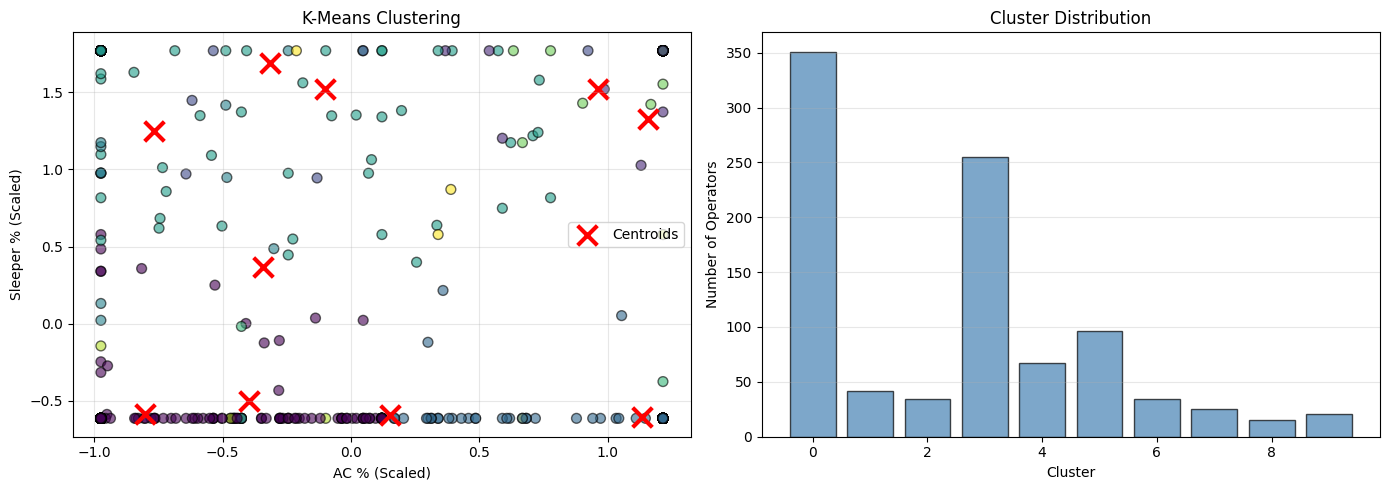


K-Means Metrics: CH=728.31, DB=0.76, Sil=0.711
Cluster sizes: {0: np.int64(351), 1: np.int64(42), 2: np.int64(34), 3: np.int64(255), 4: np.int64(67), 5: np.int64(96), 6: np.int64(34), 7: np.int64(25), 8: np.int64(15), 9: np.int64(21)}


In [53]:
# Let's try K-Means clustering first
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt

# I'll use Silhouette Score to find the best number of clusters
range_n_clusters = range(2, 11)
silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans_test = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels_test))

optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_n_clusters} (Silhouette Score: {max(silhouette_scores):.4f})")

# Apply K-Means clustering with optimal number of clusters
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Calculate evaluation metrics
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=50, edgecolors='black')
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', marker='x', s=200, linewidths=3, label='Centroids')
axes[0].set_xlabel('AC % (Scaled)')
axes[0].set_ylabel('Sleeper % (Scaled)')
axes[0].set_title('K-Means Clustering')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
axes[1].bar(cluster_counts.index, cluster_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Operators')
axes[1].set_title('Cluster Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nK-Means Metrics: CH={kmeans_ch:.2f}, DB={kmeans_db:.2f}, Sil={kmeans_sil:.3f}")
print(f"Cluster sizes: {dict(pd.Series(kmeans_labels).value_counts().sort_index())}")


Here we want to use the second model we saw in class which is the DBSCAN

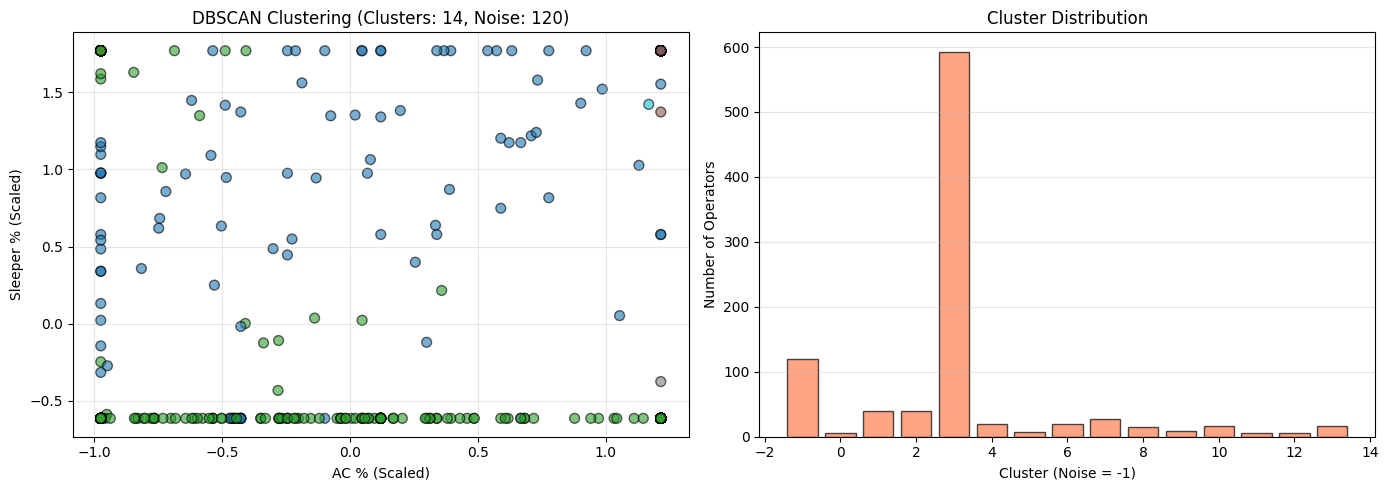


DBSCAN Metrics: CH=326.90, DB=0.27, Sil=0.668
Cluster sizes: {-1: np.int64(120), 0: np.int64(6), 1: np.int64(39), 2: np.int64(39), 3: np.int64(593), 4: np.int64(19), 5: np.int64(8), 6: np.int64(20), 7: np.int64(28), 8: np.int64(15), 9: np.int64(9), 10: np.int64(17), 11: np.int64(5), 12: np.int64(6), 13: np.int64(16)}


In [54]:
# Now let's try DBSCAN, which is good for finding clusters of different shapes
from sklearn.cluster import DBSCAN

# Let's apply DBSCAN with some reasonable parameters
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# DBSCAN can mark some points as noise (labeled -1), so let me count the actual clusters
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

# we are going to calculate metrics only for the actual clusters (not noise points)
if n_clusters_dbscan > 1:
    # Filter out noise points for metric calculation
    mask = dbscan_labels != -1
    if mask.sum() > 1:
        dbscan_ch = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_db = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    else:
        dbscan_ch = dbscan_db = dbscan_sil = np.nan
else:
    dbscan_ch = dbscan_db = dbscan_sil = np.nan

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.6, s=50, edgecolors='black')
axes[0].set_xlabel('AC % (Scaled)')
axes[0].set_ylabel('Sleeper % (Scaled)')
axes[0].set_title(f'DBSCAN Clustering (Clusters: {n_clusters_dbscan}, Noise: {n_noise})')
axes[0].grid(True, alpha=0.3)

cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()
axes[1].bar(cluster_counts.index, cluster_counts.values, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Cluster (Noise = -1)')
axes[1].set_ylabel('Number of Operators')
axes[1].set_title('Cluster Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

if not np.isnan(dbscan_ch):
    print(f"\nDBSCAN Metrics: CH={dbscan_ch:.2f}, DB={dbscan_db:.2f}, Sil={dbscan_sil:.3f}")
else:
    print("\nDBSCAN Metrics: Not available (too few clusters)")
print(f"Cluster sizes: {dict(pd.Series(dbscan_labels).value_counts().sort_index())}")


=== Clustering Methods Comparison ===


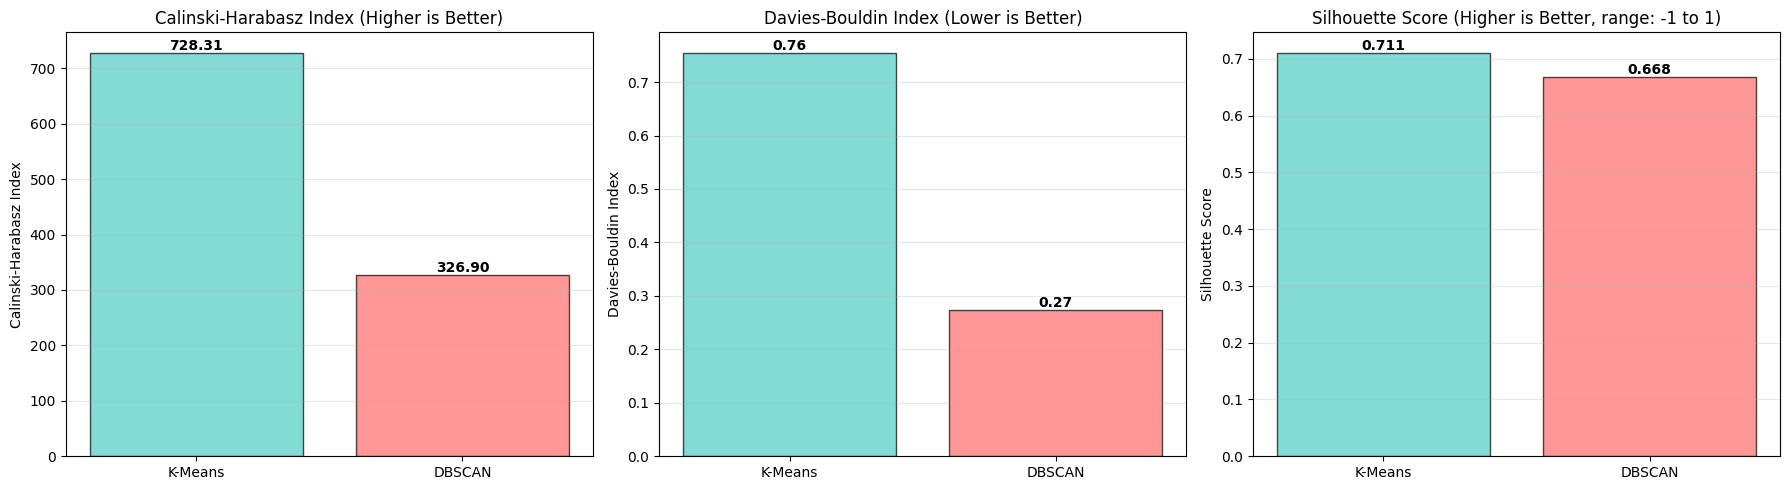

In [55]:
#we now wanr to compare both clustering methods to see which one works better
comparison_results = []

# K-Means results
comparison_results.append({
    'Method': 'K-Means',
    'Calinski-Harabasz': kmeans_ch,
    'Davies-Bouldin': kmeans_db,
    'Silhouette Score': kmeans_sil,
    'Number of Clusters': optimal_n_clusters
})

# DBSCAN results
if not np.isnan(dbscan_ch):
    comparison_results.append({
        'Method': 'DBSCAN',
        'Calinski-Harabasz': dbscan_ch,
        'Davies-Bouldin': dbscan_db,
        'Silhouette Score': dbscan_sil,
        'Number of Clusters': n_clusters_dbscan
    })
else:
    comparison_results.append({
        'Method': 'DBSCAN',
        'Calinski-Harabasz': np.nan,
        'Davies-Bouldin': np.nan,
        'Silhouette Score': np.nan,
        'Number of Clusters': n_clusters_dbscan
    })

# Agglomerative results (will be added after cell 85)
# GMM results (will be added after cell 86)

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('Silhouette Score', ascending=False, na_position='last')

print("=== Clustering Methods Comparison ===")
comparison_df

# Visualization: Comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calinski-Harabasz Index
axes[0].bar(comparison_df['Method'], comparison_df['Calinski-Harabasz'], color=['#4ecdc4', '#ff6b6b'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Calinski-Harabasz Index')
axes[0].set_title('Calinski-Harabasz Index (Higher is Better)')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Calinski-Harabasz']):
    if not np.isnan(v):
        axes[0].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Davies-Bouldin Index
axes[1].bar(comparison_df['Method'], comparison_df['Davies-Bouldin'], color=['#4ecdc4', '#ff6b6b'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index (Lower is Better)')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Davies-Bouldin']):
    if not np.isnan(v):
        axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Silhouette Score
axes[2].bar(comparison_df['Method'], comparison_df['Silhouette Score'], color=['#4ecdc4', '#ff6b6b'], alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette Score (Higher is Better, range: -1 to 1)')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Silhouette Score']):
    if not np.isnan(v):
        axes[2].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# 4) Route Clustering: Discovering Natural Route Segments

Clustering routes to find natural segments: commuter routes, night-long routes, premium routes, underserved rural lines.


In [56]:
# Now I want to cluster routes instead of operators. Let me prepare the route features
route_features = bus_df_final.groupby(['From', 'To']).agg({
    'Distance': 'mean',
    'Duration': lambda x: x.dt.total_seconds().mean() if len(x) > 0 else 0,  # Convert timedelta to seconds
    'Has A/C?': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'Sleeper Category': lambda x: (x.isin(['Sleeper', 'Semi-Sleeper']).sum()) / len(x) if len(x) > 0 else 0,
    'Is Multi-Axle?': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'Has Video?': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'Operator': 'count'  # Number of operators on this route
}).reset_index()

route_features.columns = ['From', 'To', 'avg_distance', 'avg_duration', 'pct_ac', 
                          'pct_sleeper', 'pct_multiaxle', 'pct_video', 'num_operators']

# Extract the features I need for clustering
X_route = route_features[['avg_distance', 'avg_duration', 'pct_ac', 'pct_sleeper', 
                          'pct_multiaxle', 'pct_video', 'num_operators']].values

# Scale features
scaler_route = StandardScaler()
X_route_scaled = scaler_route.fit_transform(X_route)

print(f"Number of unique routes: {len(route_features)}")
print(f"Route features shape: {X_route_scaled.shape}")
print(f"\nRoute features summary:")
print(route_features[['avg_distance', 'avg_duration', 'pct_ac', 'pct_sleeper', 'num_operators']].describe())


Number of unique routes: 10344
Route features shape: (10344, 7)

Route features summary:
       avg_distance   avg_duration        pct_ac   pct_sleeper  num_operators
count  10344.000000   10344.000000  10344.000000  10344.000000   10344.000000
mean     414.059736   34948.210154      0.395801      0.438002       3.448086
std      232.946004   18848.977094      0.428274      0.458402       5.687690
min        1.000000      60.000000      0.000000      0.000000       1.000000
25%      268.000000   23617.083333      0.000000      0.000000       1.000000
50%      388.000000   33171.000000      0.250000      0.250000       1.000000
75%      520.000000   43200.000000      1.000000      1.000000       3.000000
max     2478.000000  170280.000000      1.000000      1.000000     102.000000


Optimal number of route clusters: 4

=== Route Cluster Analysis ===

Cluster 0 (801 routes):
  Average Distance: 433.2 km
  Average Duration: 9.6 hours
  AC Percentage: 20.0%
  Sleeper Percentage: 69.9%
  Average Operators: 2.5
  Interpreted Type: Mixed Service

Cluster 1 (2507 routes):
  Average Distance: 585.6 km
  Average Duration: 13.5 hours
  AC Percentage: 76.6%
  Sleeper Percentage: 82.7%
  Average Operators: 2.4
  Interpreted Type: Night-Long/Long Distance

Cluster 2 (6608 routes):
  Average Distance: 350.1 km
  Average Duration: 8.4 hours
  AC Percentage: 27.3%
  Sleeper Percentage: 26.5%
  Average Operators: 2.6
  Interpreted Type: Mixed Service

Cluster 3 (428 routes):
  Average Distance: 361.3 km
  Average Duration: 8.1 hours
  AC Percentage: 48.5%
  Sleeper Percentage: 34.6%
  Average Operators: 25.1
  Interpreted Type: Mixed Service


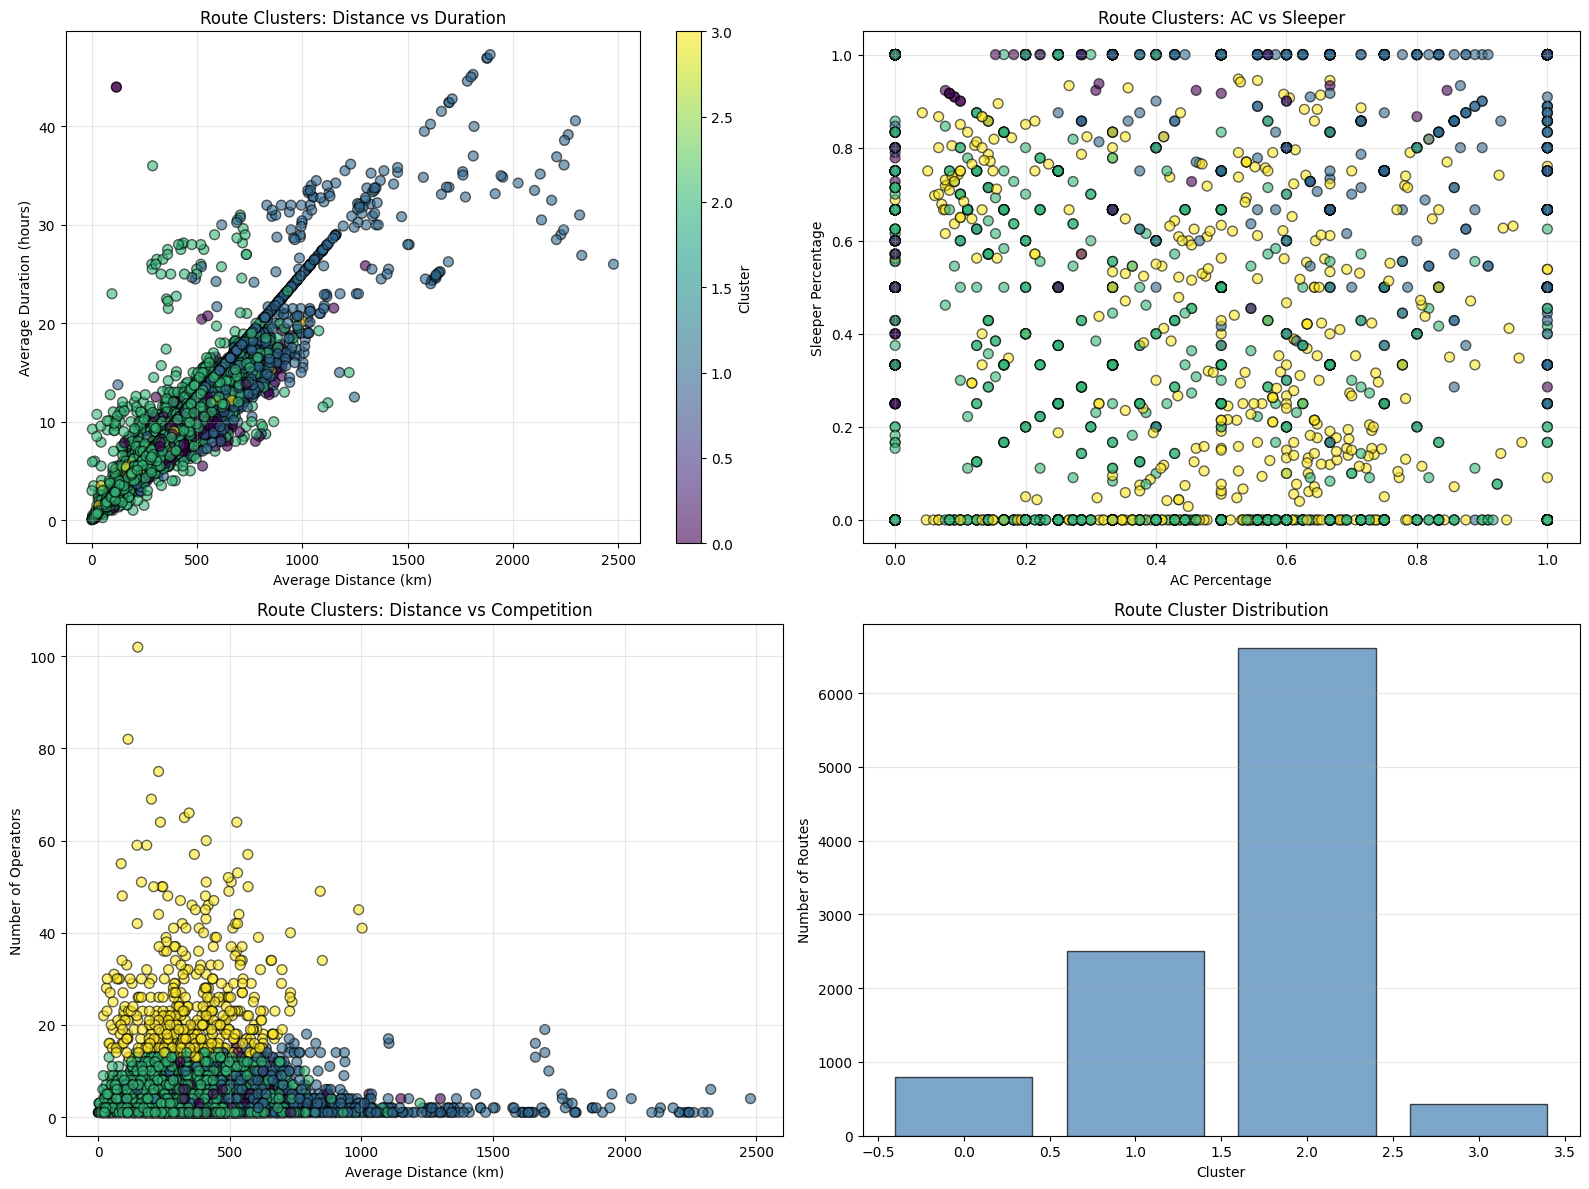

In [57]:
# Route Clustering: Find optimal number of clusters
range_n_clusters_route = range(3, 9)  # Expecting 3-8 route types
inertias_route = []
silhouette_scores_route = []

for n_clusters in range_n_clusters_route:
    kmeans_route_test = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels_route_test = kmeans_route_test.fit_predict(X_route_scaled)
    inertias_route.append(kmeans_route_test.inertia_)
    silhouette_scores_route.append(silhouette_score(X_route_scaled, labels_route_test))

optimal_n_clusters_route = range_n_clusters_route[np.argmax(silhouette_scores_route)]
print(f"Optimal number of route clusters: {optimal_n_clusters_route}")

# Apply K-Means clustering to routes
kmeans_route = KMeans(n_clusters=optimal_n_clusters_route, random_state=42, n_init=10)
route_labels = kmeans_route.fit_predict(X_route_scaled)

route_features['route_cluster'] = route_labels

# Analyze clusters to interpret them
print("\n=== Route Cluster Analysis ===")
for cluster_id in sorted(route_features['route_cluster'].unique()):
    cluster_data = route_features[route_features['route_cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_data)} routes):")
    print(f"  Average Distance: {cluster_data['avg_distance'].mean():.1f} km")
    print(f"  Average Duration: {cluster_data['avg_duration'].mean()/3600:.1f} hours")
    print(f"  AC Percentage: {cluster_data['pct_ac'].mean()*100:.1f}%")
    print(f"  Sleeper Percentage: {cluster_data['pct_sleeper'].mean()*100:.1f}%")
    print(f"  Average Operators: {cluster_data['num_operators'].mean():.1f}")
    
    # Interpret cluster type
    avg_dist = cluster_data['avg_distance'].mean()
    avg_dur = cluster_data['avg_duration'].mean() / 3600
    pct_ac = cluster_data['pct_ac'].mean()
    
    if avg_dist < 200 and avg_dur < 4:
        route_type = "Commuter/Short Distance"
    elif avg_dist > 500 and avg_dur > 8:
        route_type = "Night-Long/Long Distance"
    elif pct_ac > 0.7:
        route_type = "Premium Routes"
    elif cluster_data['num_operators'].mean() < 2:
        route_type = "Underserved/Rural"
    else:
        route_type = "Mixed Service"
    
    print(f"  Interpreted Type: {route_type}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distance vs Duration colored by cluster
scatter = axes[0, 0].scatter(route_features['avg_distance'], route_features['avg_duration']/3600, 
                             c=route_labels, cmap='viridis', alpha=0.6, s=50, edgecolors='black')
axes[0, 0].set_xlabel('Average Distance (km)')
axes[0, 0].set_ylabel('Average Duration (hours)')
axes[0, 0].set_title('Route Clusters: Distance vs Duration')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster')

# AC vs Sleeper colored by cluster
axes[0, 1].scatter(route_features['pct_ac'], route_features['pct_sleeper'], 
                   c=route_labels, cmap='viridis', alpha=0.6, s=50, edgecolors='black')
axes[0, 1].set_xlabel('AC Percentage')
axes[0, 1].set_ylabel('Sleeper Percentage')
axes[0, 1].set_title('Route Clusters: AC vs Sleeper')
axes[0, 1].grid(True, alpha=0.3)

# Distance vs Number of Operators
axes[1, 0].scatter(route_features['avg_distance'], route_features['num_operators'], 
                   c=route_labels, cmap='viridis', alpha=0.6, s=50, edgecolors='black')
axes[1, 0].set_xlabel('Average Distance (km)')
axes[1, 0].set_ylabel('Number of Operators')
axes[1, 0].set_title('Route Clusters: Distance vs Competition')
axes[1, 0].grid(True, alpha=0.3)

# Cluster distribution
cluster_counts_route = pd.Series(route_labels).value_counts().sort_index()
axes[1, 1].bar(cluster_counts_route.index, cluster_counts_route.values, 
               color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Number of Routes')
axes[1, 1].set_title('Route Cluster Distribution')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# 5) Operator Service-Level Segmentation

Clustering operators into premium vs budget vs mixed-service categories based on their service characteristics.


=== Operator Service-Level Clustering ===

Service Cluster 0 (105 operators):
  Average AC: 15.5%
  Average Sleeper: 60.7%
  Average Multi-Axle: 1.4%
  Average Video: 27.4%
  Average Pushback: 13.6%
  Average Premium Score: 0.237
  Service Type: Budget Service

Service Cluster 1 (766 operators):
  Average AC: 44.1%
  Average Sleeper: 15.7%
  Average Multi-Axle: 0.9%
  Average Video: 8.8%
  Average Pushback: 0.3%
  Average Premium Score: 0.139
  Service Type: Budget Service

Service Cluster 2 (69 operators):
  Average AC: 93.2%
  Average Sleeper: 84.9%
  Average Multi-Axle: 93.3%
  Average Video: 61.0%
  Average Pushback: 0.3%
  Average Premium Score: 0.665
  Service Type: Premium Service


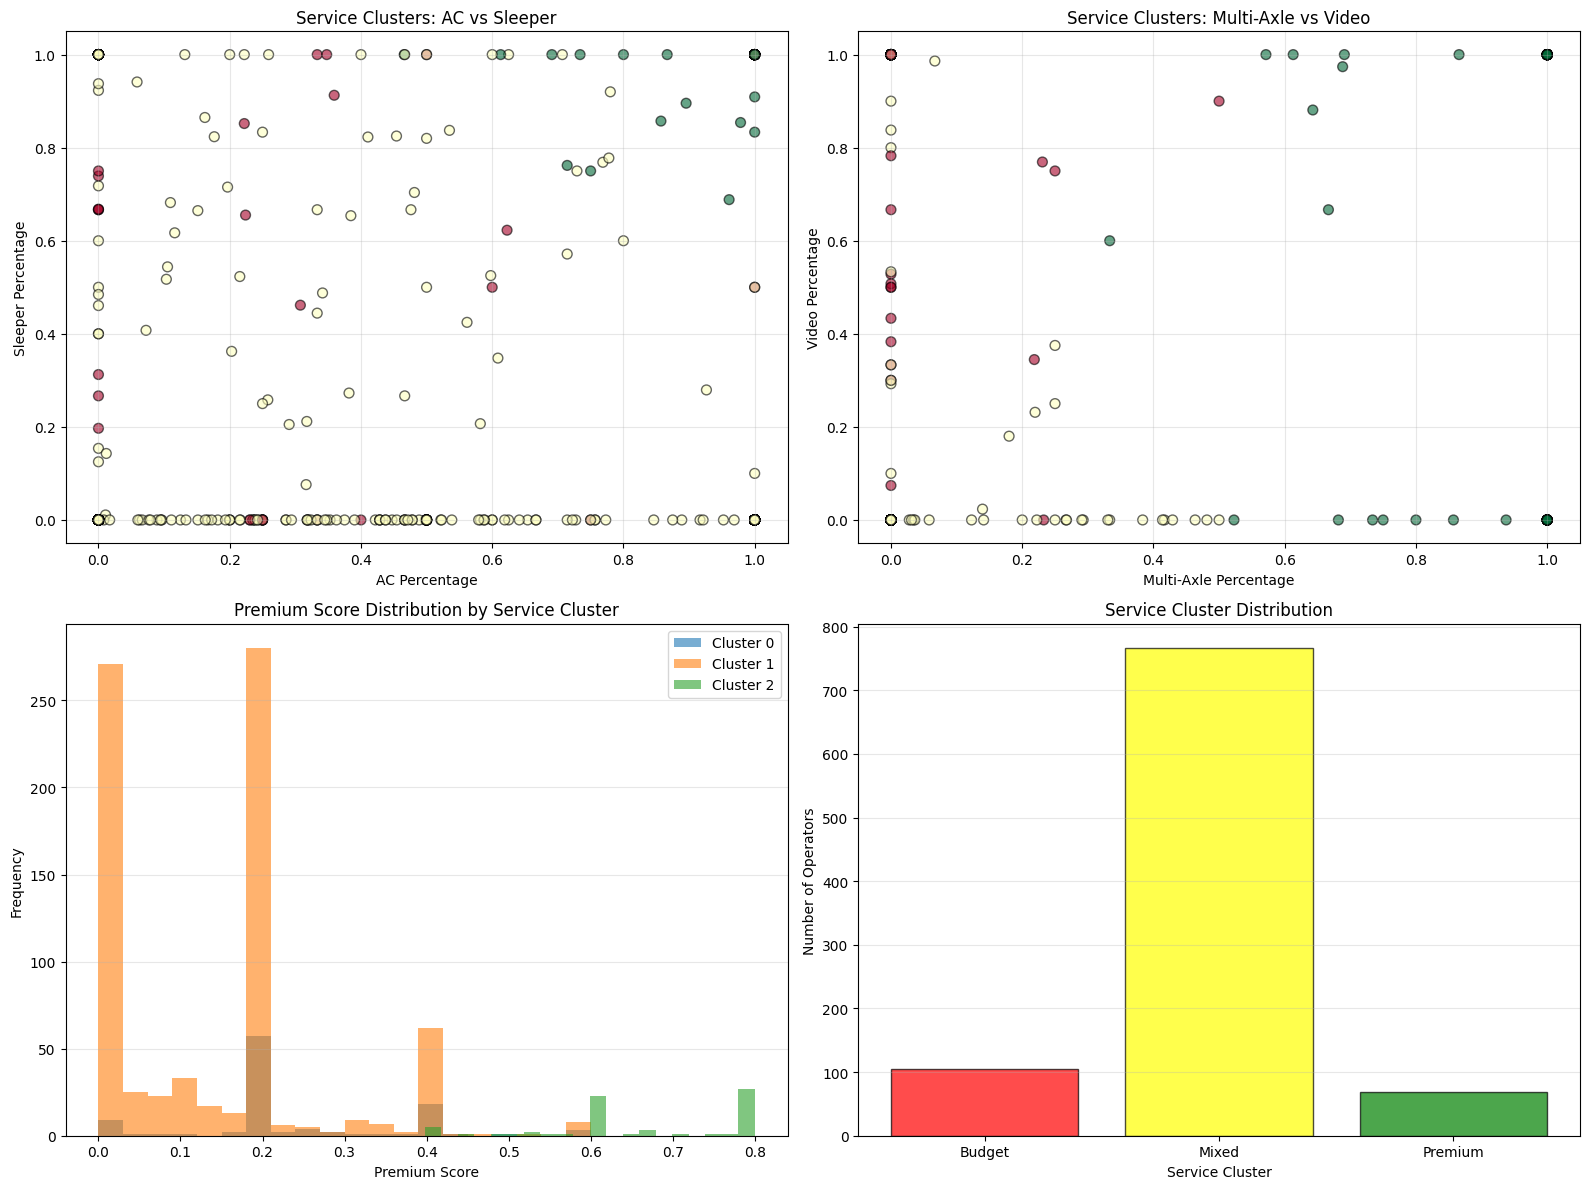


=== Example Operators by Service Cluster ===

Service Cluster 0 - Sample Operators:
  - **sharma Airbus**(sonatravels) (Sona Travels)
  - 1+2, -non Ac 35 Seater/sleeper (Sugama  Tourists)
  - Amar Travels (AP Travels)
  - Ambika Travels (Prasanna Purple)
  - Ap Tours & Travelsmumbai (AP Travels)

Service Cluster 1 - Sample Operators:
  - A J Travels
  - A1 Travels
  - ABT X Travels
  - ASHRAY TRavels
  - ASHRAY TRavels-amrutyog corona

Service Cluster 2 - Sample Operators:
  - Bangalore Mangalore Udupi Manipal By  Volvo A/c Multi-axle 2+2 Semi Sleeper (Bharathi Travels)
  - Bharathi Benz Multi-axle A/c (Sreekrishna  Travels)
  - Bharathi Mercedez Multi(sonatravels) (Sona Travels)
  - Bharathi Travels
  - Bharathi Travels (afternoon) (Bharathi Travels)


In [58]:
# Operator Service-Level Clustering (premium vs budget vs mixed)
# We already have operator_df with features, now cluster into 3 categories

# Use K-Means with 3 clusters for premium/budget/mixed
kmeans_service = KMeans(n_clusters=3, random_state=42, n_init=10)
service_labels = kmeans_service.fit_predict(X_scaled)

operator_df['service_cluster'] = service_labels

# Analyze service clusters
print("=== Operator Service-Level Clustering ===")
for cluster_id in sorted(operator_df['service_cluster'].unique()):
    cluster_data = operator_df[operator_df['service_cluster'] == cluster_id]
    print(f"\nService Cluster {cluster_id} ({len(cluster_data)} operators):")
    print(f"  Average AC: {cluster_data['pct_ac'].mean()*100:.1f}%")
    print(f"  Average Sleeper: {cluster_data['pct_sleeper'].mean()*100:.1f}%")
    print(f"  Average Multi-Axle: {cluster_data['pct_multiaxle'].mean()*100:.1f}%")
    print(f"  Average Video: {cluster_data['pct_video'].mean()*100:.1f}%")
    print(f"  Average Pushback: {cluster_data['pct_pushback'].mean()*100:.1f}%")
    
    # Calculate premium score
    premium_score_cluster = (cluster_data['pct_ac'].mean() + 
                             cluster_data['pct_sleeper'].mean() + 
                             cluster_data['pct_multiaxle'].mean() + 
                             cluster_data['pct_video'].mean() + 
                             cluster_data['pct_pushback'].mean()) / 5
    print(f"  Average Premium Score: {premium_score_cluster:.3f}")
    
    # Interpret service level
    if premium_score_cluster > 0.6:
        service_type = "Premium Service"
    elif premium_score_cluster < 0.3:
        service_type = "Budget Service"
    else:
        service_type = "Mixed Service"
    
    print(f"  Service Type: {service_type}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# AC vs Sleeper colored by service cluster
axes[0, 0].scatter(operator_df['pct_ac'], operator_df['pct_sleeper'], 
                   c=service_labels, cmap='RdYlGn', alpha=0.6, s=50, edgecolors='black')
axes[0, 0].set_xlabel('AC Percentage')
axes[0, 0].set_ylabel('Sleeper Percentage')
axes[0, 0].set_title('Service Clusters: AC vs Sleeper')
axes[0, 0].grid(True, alpha=0.3)

# Multi-Axle vs Video
axes[0, 1].scatter(operator_df['pct_multiaxle'], operator_df['pct_video'], 
                   c=service_labels, cmap='RdYlGn', alpha=0.6, s=50, edgecolors='black')
axes[0, 1].set_xlabel('Multi-Axle Percentage')
axes[0, 1].set_ylabel('Video Percentage')
axes[0, 1].set_title('Service Clusters: Multi-Axle vs Video')
axes[0, 1].grid(True, alpha=0.3)

# Premium score distribution by cluster
for cluster_id in sorted(operator_df['service_cluster'].unique()):
    cluster_data = operator_df[operator_df['service_cluster'] == cluster_id]
    premium_scores = (cluster_data['pct_ac'] + cluster_data['pct_sleeper'] + 
                     cluster_data['pct_multiaxle'] + cluster_data['pct_video'] + 
                     cluster_data['pct_pushback']) / 5
    axes[1, 0].hist(premium_scores, alpha=0.6, label=f'Cluster {cluster_id}', bins=20)
axes[1, 0].set_xlabel('Premium Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Premium Score Distribution by Service Cluster')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Service cluster distribution
service_counts = pd.Series(service_labels).value_counts().sort_index()
axes[1, 1].bar(service_counts.index, service_counts.values, 
               color=['red', 'yellow', 'green'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Service Cluster')
axes[1, 1].set_ylabel('Number of Operators')
axes[1, 1].set_title('Service Cluster Distribution')
axes[1, 1].set_xticks(service_counts.index)
axes[1, 1].set_xticklabels(['Budget', 'Mixed', 'Premium'])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Show some examples
print("\n=== Example Operators by Service Cluster ===")
for cluster_id in sorted(operator_df['service_cluster'].unique()):
    cluster_data = operator_df[operator_df['service_cluster'] == cluster_id].head(5)
    print(f"\nService Cluster {cluster_id} - Sample Operators:")
    for idx, row in cluster_data.iterrows():
        print(f"  - {row['Operator']}")


# Supervised Classification: Premium vs Budget Operators

Now I'll try to classify operators as premium or budget using supervised learning. I already know which ones are which, so I can train models on that.

Using supervised learning models (Logistic Regression, KNN, Decision Tree, Gradient Boosting) to classify operators into premium and budget categories.


In [59]:
# Prepare data for supervised classification
from sklearn.model_selection import train_test_split

# Features and target
X_class = operator_df[['pct_ac', 'pct_sleeper', 'pct_seater', 'pct_multiaxle', 'pct_video', 'pct_pushback']].values
y_class = np.array([1 if cat == 'premium' else 0 for cat in category_labels])  # 1 = premium, 0 = budget

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

# Scale features
scaler_class = StandardScaler()
X_train_scaled = scaler_class.fit_transform(X_train)
X_test_scaled = scaler_class.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Premium in training: {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"Budget in training: {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")


Training set size: 752
Test set size: 188
Premium in training: 430 (57.2%)
Budget in training: 322 (42.8%)


# Service Adequacy Classification

I want to figure out if routes have the right level of service. For example, long routes or night routes should probably have AC and sleeper options, right?


In [60]:
"""
Create target variable: Should route have AC/Sleeper?
Rules: 1 = SHOULD have AC/Sleeper if:
   - Long distance (>400km) OR
   - Long duration (>6 hours) OR  
   - Night travel (departure/arrival between 8PM-6AM)
"""

# Check if route should have premium features
def should_have_premium(row):
    distance = row['Distance']
    duration = row['Duration'].total_seconds() / 3600 if pd.notna(row['Duration']) else 0  # hours
    departure = pd.to_datetime(row['Departure'], format='%I:%M:%S %p', errors='coerce')
    arrival = pd.to_datetime(row['Arrival'], format='%I:%M:%S %p', errors='coerce')
    
    # Long distance or duration
    if distance > 400 or duration > 6:
        return 1
    
    # Night travel (8PM to 6AM)
    if pd.notna(departure) and pd.notna(arrival):
        dep_hour = departure.hour
        arr_hour = arrival.hour
        if dep_hour >= 20 or dep_hour < 6 or arr_hour >= 20 or arr_hour < 6:
            return 1
    
    return 0

# Create target for each route
bus_df_final['should_have_premium'] = bus_df_final.apply(should_have_premium, axis=1)

# Aggregate at route level (From-To)
route_adequacy = bus_df_final.groupby(['From', 'To']).agg({
    'should_have_premium': 'max',  # If any trip should have premium, route should
    'Has A/C?': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'Sleeper Category': lambda x: (x.isin(['Sleeper', 'Semi-Sleeper']).sum() / len(x) if len(x) > 0 else 0),
    'Distance': 'mean',
    'Duration': lambda x: x.dt.total_seconds().mean() if len(x) > 0 else 0  # Convert timedelta to seconds
}).reset_index()

route_adequacy.columns = ['From', 'To', 'should_have_premium', 'has_ac_pct', 'has_sleeper_pct', 'distance', 'duration']

# Create actual premium indicator (has AC OR Sleeper)
route_adequacy['has_premium'] = ((route_adequacy['has_ac_pct'] > 0.5) | 
                                 (route_adequacy['has_sleeper_pct'] > 0.5)).astype(int)

# Target: 1 = adequate (should have AND has it, OR shouldn't have)
#         0 = inadequate (should have BUT doesn't have it)
route_adequacy['is_adequate'] = ((route_adequacy['should_have_premium'] == 1) & 
                                 (route_adequacy['has_premium'] == 1)).astype(int)
# Routes that shouldn't have premium are also considered adequate
route_adequacy.loc[route_adequacy['should_have_premium'] == 0, 'is_adequate'] = 1

print(f"Routes that SHOULD have premium: {(route_adequacy['should_have_premium'] == 1).sum()}")
print(f"Routes that HAVE premium: {(route_adequacy['has_premium'] == 1).sum()}")
print(f"Adequate routes: {(route_adequacy['is_adequate'] == 1).sum()}")
print(f"Inadequate routes: {(route_adequacy['is_adequate'] == 0).sum()}")


Routes that SHOULD have premium: 10113
Routes that HAVE premium: 6119
Adequate routes: 6184
Inadequate routes: 4160


In [61]:
# Prepare features for classification
X_adequacy = route_adequacy[['distance', 'duration', 'has_ac_pct', 'has_sleeper_pct']].values
y_adequacy = route_adequacy['is_adequate'].values

# Split data
X_train_adeq, X_test_adeq, y_train_adeq, y_test_adeq = train_test_split(
    X_adequacy, y_adequacy, test_size=0.2, random_state=42, stratify=y_adequacy)

# Scale features
scaler_adeq = StandardScaler()
X_train_adeq_scaled = scaler_adeq.fit_transform(X_train_adeq)
X_test_adeq_scaled = scaler_adeq.transform(X_test_adeq)

print(f"Training: {len(X_train_adeq)}, Test: {len(X_test_adeq)}")
print(f"Adequate in train: {np.sum(y_train_adeq == 1)} ({np.sum(y_train_adeq == 1)/len(y_train_adeq)*100:.1f}%)")


Training: 8275, Test: 2069
Adequate in train: 4947 (59.8%)


=== Service Adequacy Classification Results ===


,Model,Accuracy
3,Gradient Boosting,0.995167
2,Decision Tree,0.993233
1,KNN,0.984534
0,Logistic Regression,0.954084


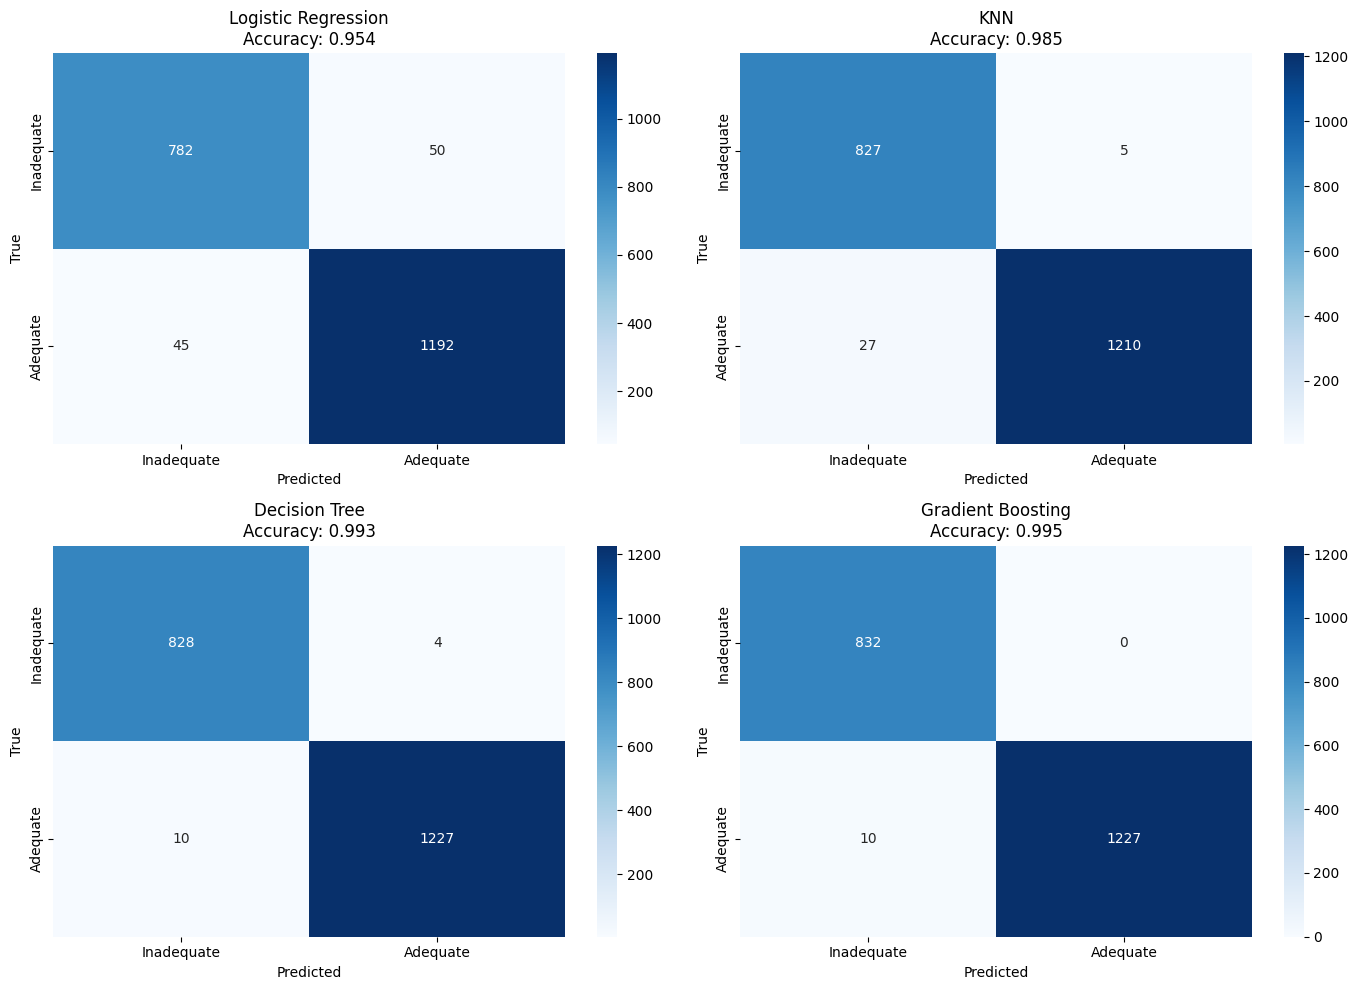

In [64]:
from sklearn.ensemble import GradientBoostingClassifier
import seaborn as sns

# Train models for Service Adequacy Classification
models_adequacy = {}
results_adequacy = {}

# Logistic Regression
lr_adeq = LogisticRegression(random_state=42, max_iter=1000)
lr_adeq.fit(X_train_adeq_scaled, y_train_adeq)
y_pred_lr_adeq = lr_adeq.predict(X_test_adeq_scaled)
models_adequacy['Logistic Regression'] = lr_adeq
results_adequacy['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test_adeq, y_pred_lr_adeq),
    'report': classification_report(y_test_adeq, y_pred_lr_adeq, target_names=['Inadequate', 'Adequate'])
}

# KNN
knn_adeq = KNeighborsClassifier(n_neighbors=5)
knn_adeq.fit(X_train_adeq_scaled, y_train_adeq)
y_pred_knn_adeq = knn_adeq.predict(X_test_adeq_scaled)
models_adequacy['KNN'] = knn_adeq
results_adequacy['KNN'] = {
    'accuracy': accuracy_score(y_test_adeq, y_pred_knn_adeq),
    'report': classification_report(y_test_adeq, y_pred_knn_adeq, target_names=['Inadequate', 'Adequate'])
}

# Decision Tree
dt_adeq = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_adeq.fit(X_train_adeq_scaled, y_train_adeq)
y_pred_dt_adeq = dt_adeq.predict(X_test_adeq_scaled)
models_adequacy['Decision Tree'] = dt_adeq
results_adequacy['Decision Tree'] = {
    'accuracy': accuracy_score(y_test_adeq, y_pred_dt_adeq),
    'report': classification_report(y_test_adeq, y_pred_dt_adeq, target_names=['Inadequate', 'Adequate'])
}

# Gradient Boosting
gb_adeq = GradientBoostingClassifier(random_state=42, n_estimators=100)
gb_adeq.fit(X_train_adeq_scaled, y_train_adeq)
y_pred_gb_adeq = gb_adeq.predict(X_test_adeq_scaled)
models_adequacy['Gradient Boosting'] = gb_adeq
results_adequacy['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_test_adeq, y_pred_gb_adeq),
    'report': classification_report(y_test_adeq, y_pred_gb_adeq, target_names=['Inadequate', 'Adequate'])
}

# Summary
summary_adequacy = pd.DataFrame({
    'Model': list(results_adequacy.keys()),
    'Accuracy': [results_adequacy[m]['accuracy'] for m in results_adequacy.keys()]
}).sort_values('Accuracy', ascending=False)

print("=== Service Adequacy Classification Results ===")
display(summary_adequacy)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (model_name, model) in enumerate(models_adequacy.items()):
    row = idx // 2
    col = idx % 2
    y_pred = model.predict(X_test_adeq_scaled)
    cm = confusion_matrix(y_test_adeq, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                xticklabels=['Inadequate', 'Adequate'], yticklabels=['Inadequate', 'Adequate'])
    axes[row, col].set_title(f'{model_name}\nAccuracy: {results_adequacy[model_name]["accuracy"]:.3f}')
    axes[row, col].set_ylabel('True')
    axes[row, col].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


=== Logistic Regression ===
Train Accuracy: 0.9814
Test Accuracy: 0.9787

Classification Report (Test):
              precision    recall  f1-score   support

      Budget       1.00      0.95      0.97        81
     Premium       0.96      1.00      0.98       107

    accuracy                           0.98       188
   macro avg       0.98      0.98      0.98       188
weighted avg       0.98      0.98      0.98       188



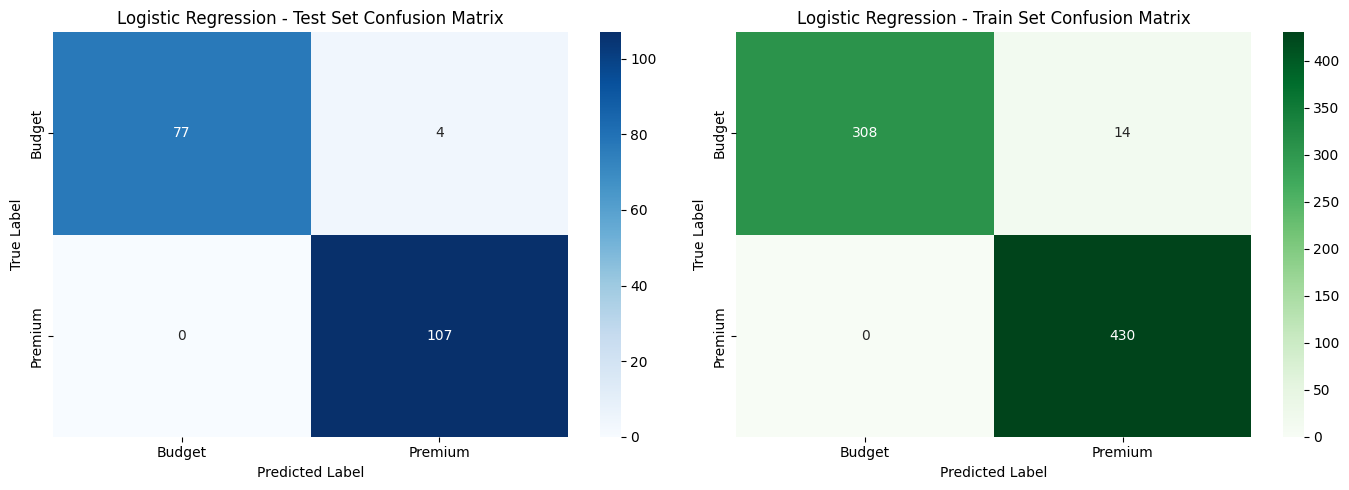

In [65]:
# Starting with Logistic Regression - it's simple and interpretable

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

print("=== Logistic Regression ===")
print(f"Train Accuracy: {train_acc_lr:.4f}")
print(f"Test Accuracy: {test_acc_lr:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_lr, target_names=['Budget', 'Premium']))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Budget', 'Premium'], yticklabels=['Budget', 'Premium'])
axes[0].set_title('Logistic Regression - Test Set Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred_lr)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Budget', 'Premium'], yticklabels=['Budget', 'Premium'])
axes[1].set_title('Logistic Regression - Train Set Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


Optimal k: 9

=== K-Nearest Neighbors (KNN) ===
Train Accuracy: 0.9867
Test Accuracy: 1.0000

Classification Report (Test):
              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00        81
     Premium       1.00      1.00      1.00       107

    accuracy                           1.00       188
   macro avg       1.00      1.00      1.00       188
weighted avg       1.00      1.00      1.00       188



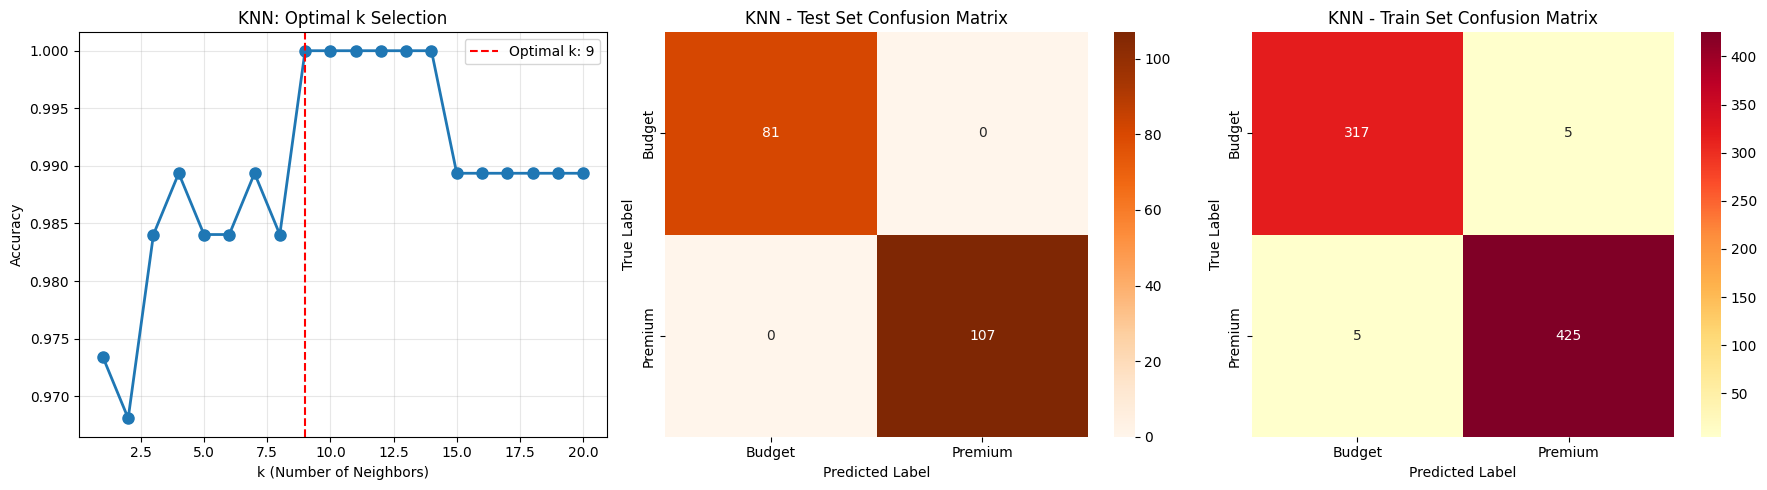

In [66]:
# K-Nearest Neighbors is next - it's intuitive and works well for classification

# We need to find the best value for k (number of neighbors)
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn_test = KNeighborsClassifier(n_neighbors=k)
    knn_test.fit(X_train_scaled, y_train)
    scores = knn_test.score(X_test_scaled, y_test)
    k_scores.append(scores)

optimal_k = k_range[np.argmax(k_scores)]
print(f"Optimal k: {optimal_k}")

# Train with optimal k
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)

y_train_pred_knn = knn.predict(X_train_scaled)
y_test_pred_knn = knn.predict(X_test_scaled)

train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)

print("\n=== K-Nearest Neighbors (KNN) ===")
print(f"Train Accuracy: {train_acc_knn:.4f}")
print(f"Test Accuracy: {test_acc_knn:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_knn, target_names=['Budget', 'Premium']))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K selection plot
axes[0].plot(k_range, k_scores, 'o-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k: {optimal_k}')
axes[0].set_xlabel('k (Number of Neighbors)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('KNN: Optimal k Selection')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred_knn)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Budget', 'Premium'], yticklabels=['Budget', 'Premium'])
axes[1].set_title('KNN - Test Set Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred_knn)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2],
            xticklabels=['Budget', 'Premium'], yticklabels=['Budget', 'Premium'])
axes[2].set_title('KNN - Train Set Confusion Matrix')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


=== Decision Tree ===
Train Accuracy: 1.0000
Test Accuracy: 0.9894

Classification Report (Test):
              precision    recall  f1-score   support

      Budget       0.98      1.00      0.99        81
     Premium       1.00      0.98      0.99       107

    accuracy                           0.99       188
   macro avg       0.99      0.99      0.99       188
weighted avg       0.99      0.99      0.99       188



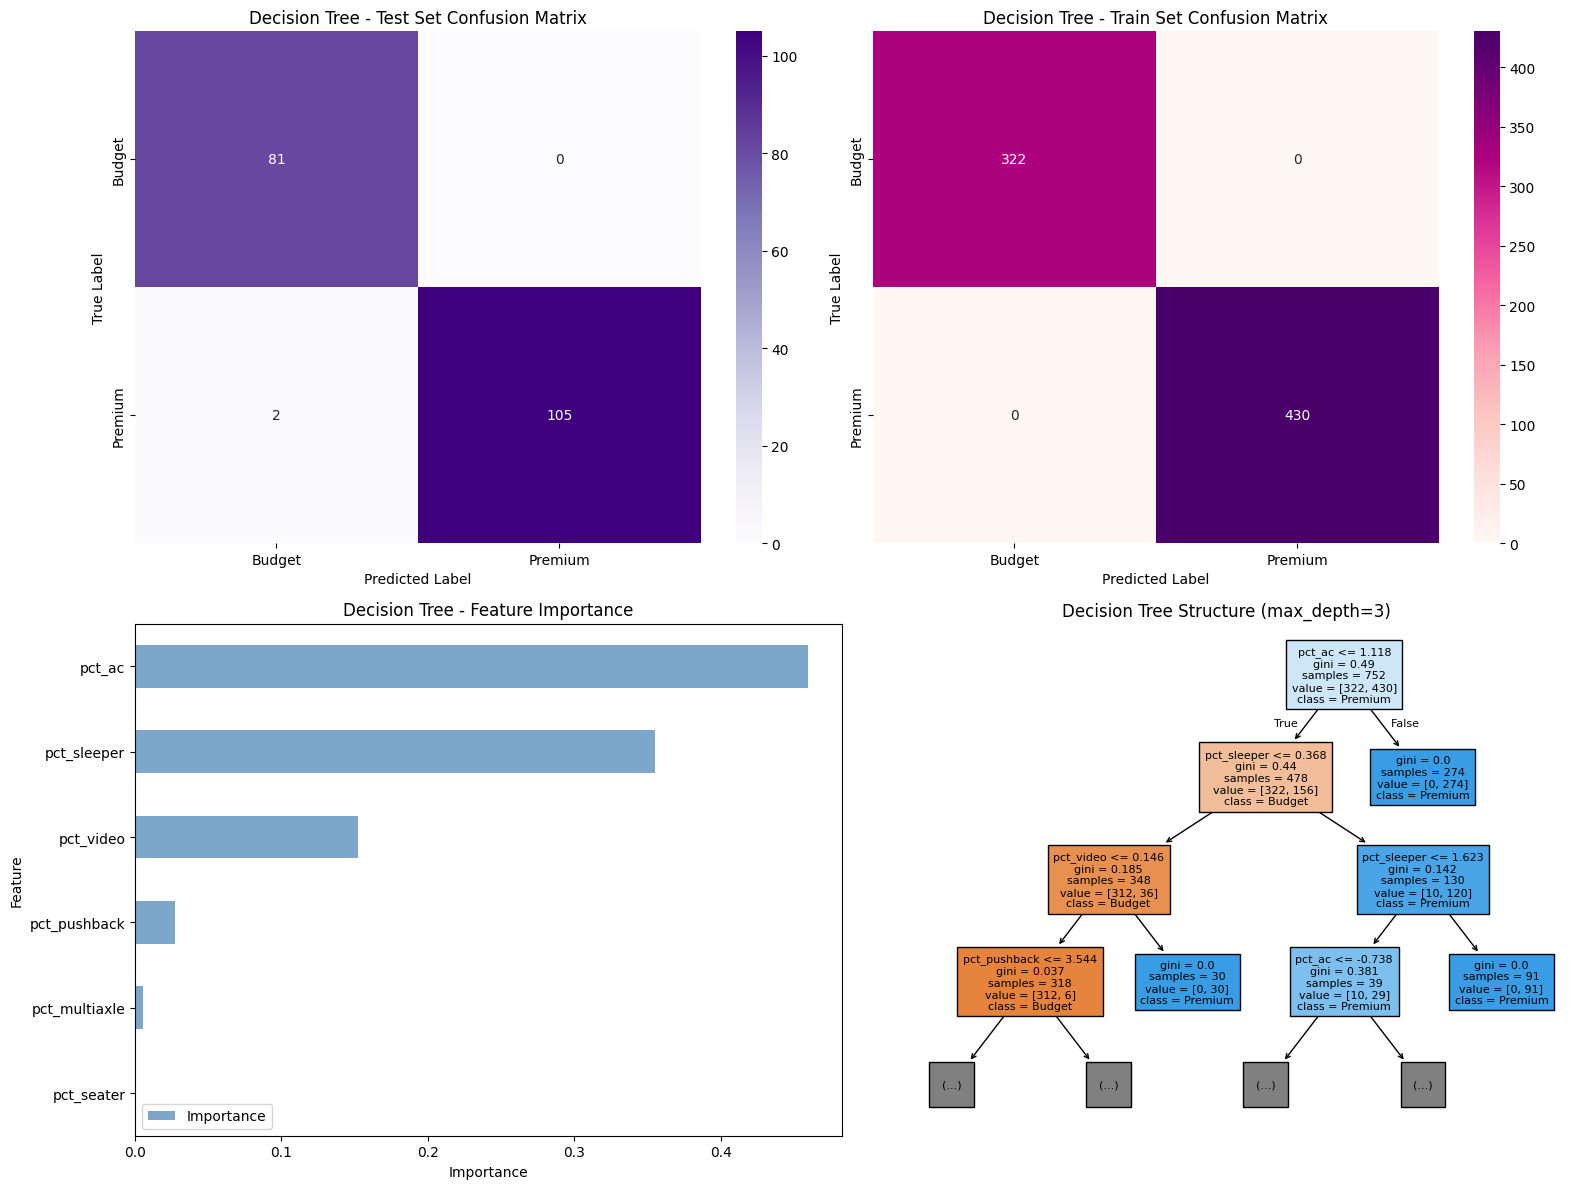

In [67]:
# Decision Trees are great because I can see exactly how they make decisions
from sklearn.tree import plot_tree

dt = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=5)
dt.fit(X_train_scaled, y_train)

y_train_pred_dt = dt.predict(X_train_scaled)
y_test_pred_dt = dt.predict(X_test_scaled)

train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

print("=== Decision Tree ===")
print(f"Train Accuracy: {train_acc_dt:.4f}")
print(f"Test Accuracy: {test_acc_dt:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_dt, target_names=['Budget', 'Premium']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred_dt)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Purples', ax=axes[0, 0],
            xticklabels=['Budget', 'Premium'], yticklabels=['Budget', 'Premium'])
axes[0, 0].set_title('Decision Tree - Test Set Confusion Matrix')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred_dt)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='RdPu', ax=axes[0, 1],
            xticklabels=['Budget', 'Premium'], yticklabels=['Budget', 'Premium'])
axes[0, 1].set_title('Decision Tree - Train Set Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# Feature Importance
feature_names = ['pct_ac', 'pct_sleeper', 'pct_seater', 'pct_multiaxle', 'pct_video', 'pct_pushback']
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)

feature_importance.plot(x='Feature', y='Importance', kind='barh', ax=axes[1, 0], color='steelblue', alpha=0.7)
axes[1, 0].set_title('Decision Tree - Feature Importance')
axes[1, 0].set_xlabel('Importance')

# Tree visualization (simplified)
plot_tree(dt, max_depth=3, feature_names=feature_names, class_names=['Budget', 'Premium'], 
          filled=True, ax=axes[1, 1], fontsize=8)
axes[1, 1].set_title('Decision Tree Structure (max_depth=3)')

plt.tight_layout()
plt.show()


=== Gradient Boosting ===
Train Accuracy: 1.0000
Test Accuracy: 0.9894

Classification Report (Test):
              precision    recall  f1-score   support

      Budget       0.98      1.00      0.99        81
     Premium       1.00      0.98      0.99       107

    accuracy                           0.99       188
   macro avg       0.99      0.99      0.99       188
weighted avg       0.99      0.99      0.99       188



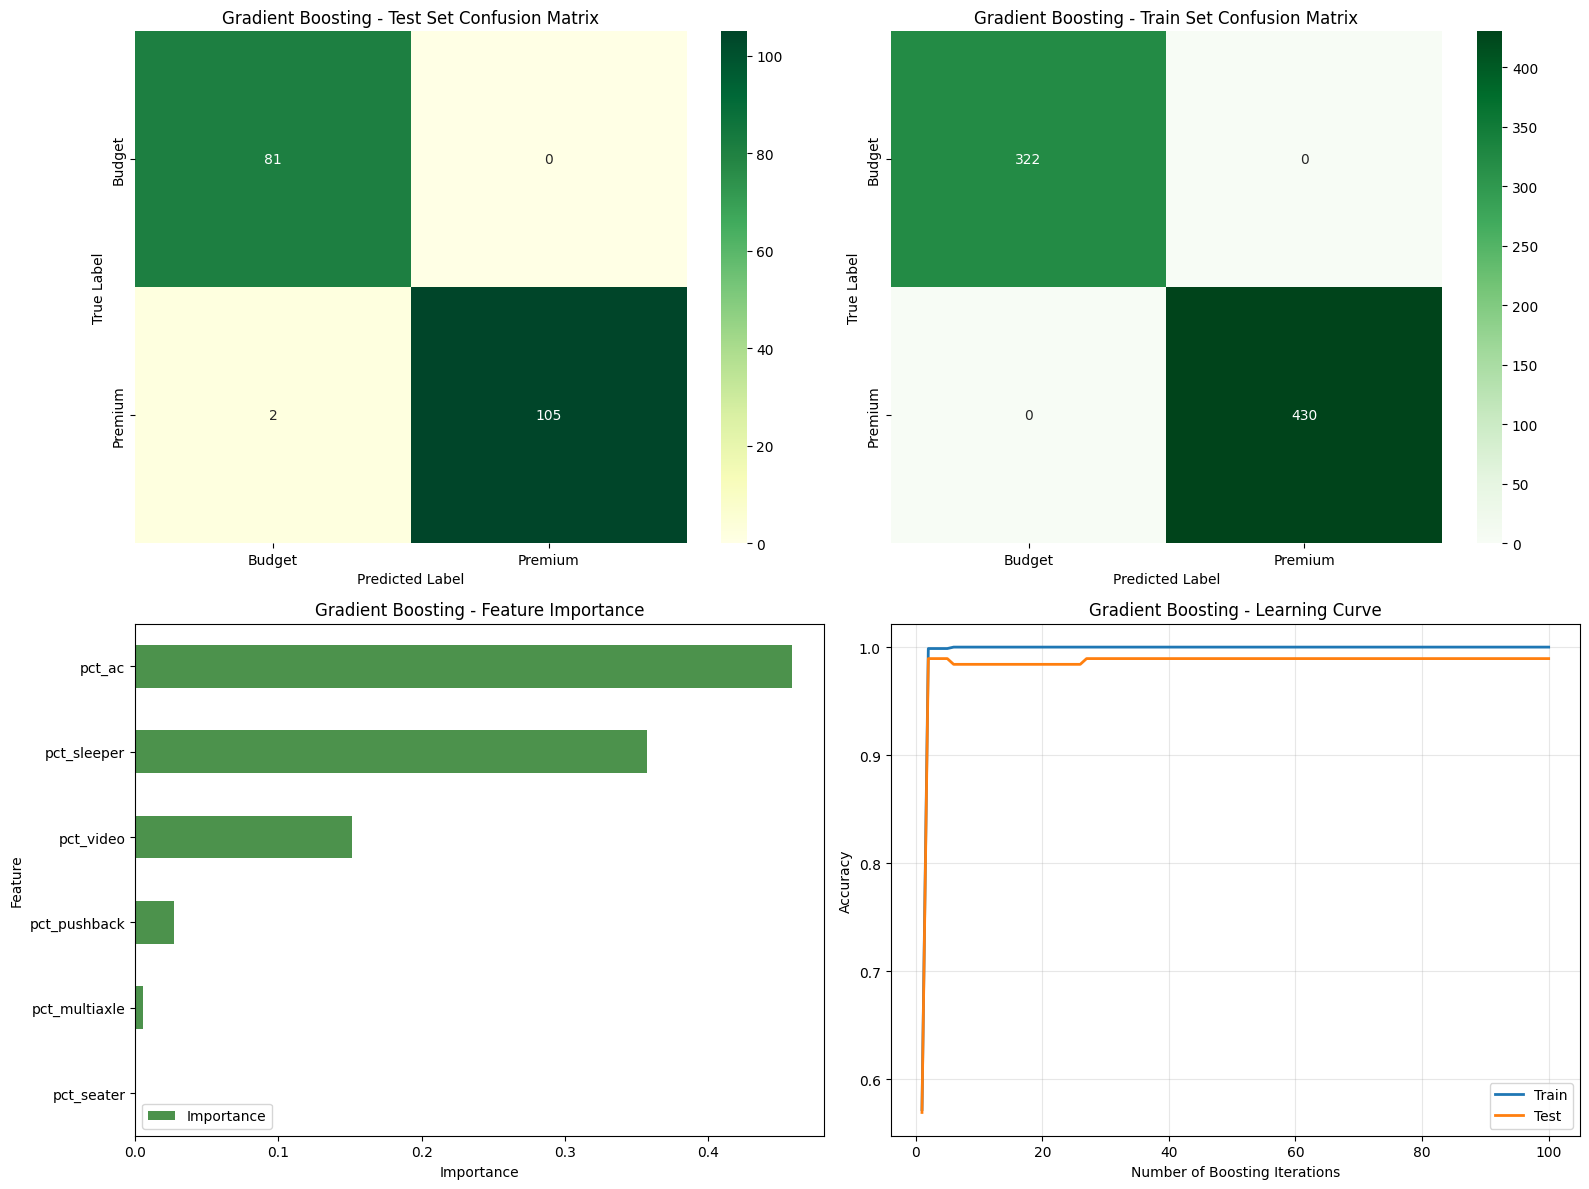

In [68]:
# Finally, Gradient Boosting - usually gives really good results
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1)
gb.fit(X_train_scaled, y_train)

y_train_pred_gb = gb.predict(X_train_scaled)
y_test_pred_gb = gb.predict(X_test_scaled)

train_acc_gb = accuracy_score(y_train, y_train_pred_gb)
test_acc_gb = accuracy_score(y_test, y_test_pred_gb)

print("=== Gradient Boosting ===")
print(f"Train Accuracy: {train_acc_gb:.4f}")
print(f"Test Accuracy: {test_acc_gb:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_gb, target_names=['Budget', 'Premium']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred_gb)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='YlGn', ax=axes[0, 0],
            xticklabels=['Budget', 'Premium'], yticklabels=['Budget', 'Premium'])
axes[0, 0].set_title('Gradient Boosting - Test Set Confusion Matrix')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred_gb)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Budget', 'Premium'], yticklabels=['Budget', 'Premium'])
axes[0, 1].set_title('Gradient Boosting - Train Set Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# Feature Importance
feature_importance_gb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=True)

feature_importance_gb.plot(x='Feature', y='Importance', kind='barh', ax=axes[1, 0], color='darkgreen', alpha=0.7)
axes[1, 0].set_title('Gradient Boosting - Feature Importance')
axes[1, 0].set_xlabel('Importance')

# Learning curve (train score vs test score over iterations)
train_scores = []
test_scores = []
for i, y_pred in enumerate(gb.staged_predict(X_train_scaled)):
    train_scores.append(accuracy_score(y_train, y_pred))
for i, y_pred in enumerate(gb.staged_predict(X_test_scaled)):
    test_scores.append(accuracy_score(y_test, y_pred))

axes[1, 1].plot(range(1, len(train_scores) + 1), train_scores, label='Train', linewidth=2)
axes[1, 1].plot(range(1, len(test_scores) + 1), test_scores, label='Test', linewidth=2)
axes[1, 1].set_xlabel('Number of Boosting Iterations')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Gradient Boosting - Learning Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== Classification Models Comparison ===


,Model,Train Accuracy,Test Accuracy
1,KNN,0.986702,1.000000
2,Decision Tree,1.000000,0.989362
3,Gradient Boosting,1.000000,0.989362
0,Logistic Regression,0.981383,0.978723


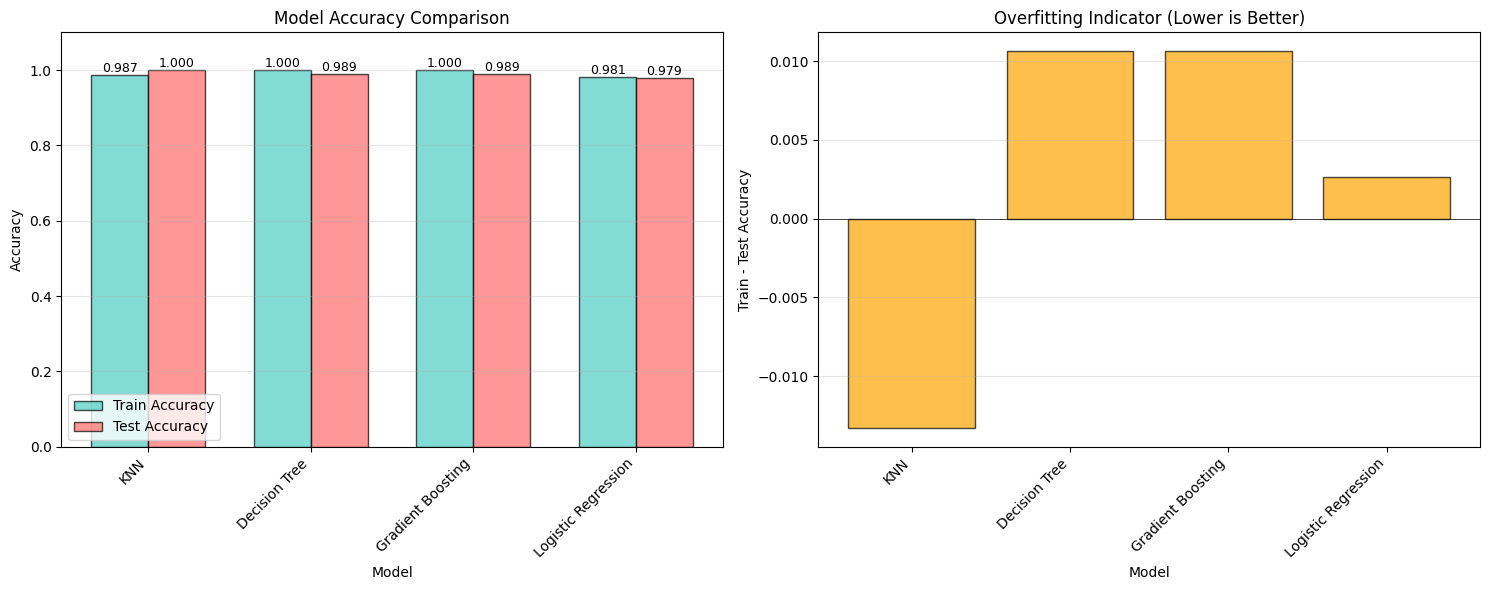

In [69]:
# Comparison of all classification models
comparison_classification = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Gradient Boosting'],
    'Train Accuracy': [train_acc_lr, train_acc_knn, train_acc_dt, train_acc_gb],
    'Test Accuracy': [test_acc_lr, test_acc_knn, test_acc_dt, test_acc_gb]
})

comparison_classification = comparison_classification.sort_values('Test Accuracy', ascending=False)
print("=== Classification Models Comparison ===")
display(comparison_classification)

# Visualization: Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison bar chart
x = np.arange(len(comparison_classification))
width = 0.35

bars1 = axes[0].bar(x - width/2, comparison_classification['Train Accuracy'], width, 
                    label='Train Accuracy', color='#4ecdc4', alpha=0.7, edgecolor='black')
bars2 = axes[0].bar(x + width/2, comparison_classification['Test Accuracy'], width, 
                    label='Test Accuracy', color='#ff6b6b', alpha=0.7, edgecolor='black')

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_classification['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Accuracy difference (overfitting indicator)
comparison_classification['Accuracy Difference'] = comparison_classification['Train Accuracy'] - comparison_classification['Test Accuracy']
axes[1].bar(x, comparison_classification['Accuracy Difference'], color='orange', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Train - Test Accuracy')
axes[1].set_title('Overfitting Indicator (Lower is Better)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_classification['Model'], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()


In [71]:
# Additional: Clustering on reduced dimensions (optional analysis)
# You can also apply clustering directly on PCA/UMAP/t-SNE reduced data
# This can help visualize how clusters appear in the reduced space
from umap.umap_ import X_umap
print("=== Summary ===")
print(f"Original features: {X_cluster.shape[1]}")
print(f"PCA 2D projection variance explained: {pca.explained_variance_ratio_.sum():.2%}")
if X_umap is not None:
    print("UMAP reduction: Completed")
print("t-SNE reduction: Completed")
print(f"\nK-Means: {len(set(kmeans_labels))} clusters")
print(f"DBSCAN: {n_clusters_dbscan} clusters, {n_noise} noise points")


ImportError: cannot import name 'X_umap' from 'umap.umap_' (/home/grgur1991/Downloads/Medium_Secret/University/Programming/Python/src/venvol/lib/python3.11/site-packages/umap/umap_.py)